In [1]:
#!echo $PYTHONPATH
!pip install ortools --target=/usr/local/lib/swan/nb_term_lib/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.9 MB/s eta 0:00:00
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 59.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 59.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 55.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 40.7 MB/s eta 0:00:00
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
ERROR: pip's dependency resolver does not currently take into account all the packa

# start

In [2]:
import sys
sys.path.append('..')
import os

import awkward as ak
import numpy as np
import uproot as uproot
import matplotlib.pyplot as plt
import mplhep as hep
import vector as vec
import matplotlib
from tqdm import tqdm
import pandas as pd

from Timing.plotting import *
from Timing.utils import *

from numba import prange, njit
import awkward.numba

plt.style.use(hep.style.CMS)
%matplotlib inline

In [3]:
def arr(x): 
    return np.asarray(x, dtype=float) 

In [4]:
@njit
def flatten_numba(a):
    return [x[0] if len(x) else 0 for x in a]

def dist(refEta, refPhi, otherTsEta, otherTsPhi):
    return ((otherTsEta-refEta)**2 + (otherTsPhi-refPhi)**2)**0.5

def distWrap2(refEta, refPhi, otherTsEta, otherTsPhi):
    deltaPhi = otherTsPhi - refPhi
    deltaPhi = (deltaPhi + np.pi) % (2 * np.pi) - np.pi
    return ((otherTsEta - refEta) ** 2 + deltaPhi ** 2)

@njit
def distWrap2_numba(refEta, refPhi, otherTsEta, otherTsPhi):
    deltaPhi = otherTsPhi - refPhi
    deltaPhi = (deltaPhi + np.pi) % (2 * np.pi) - np.pi
    return ((otherTsEta - refEta) ** 2 + deltaPhi ** 2)

@njit
def dist_numba(refEta, refPhi, otherTsEta, otherTsPhi):
    out = []
    for i in range(len(otherTsEta)):
        distance = ((otherTsEta[i] - refEta) ** 2 + (otherTsPhi[i] - refPhi) ** 2) ** 0.5
        out.append(distance)
    return np.array(out)

@njit
def distWrap_numba(refEta, refPhi, otherTsEta, otherTsPhi):
    out = []
    for i in range(len(otherTsEta)):
        deltaPhi = otherTsPhi[i] - refPhi
        deltaPhi = (deltaPhi + np.pi) % (2 * np.pi) - np.pi
        distance = ((otherTsEta[i] - refEta) ** 2 + deltaPhi ** 2) ** 0.5
        out.append(distance)
    return np.array(out)
   
def find_track_id(array, number):
    try:
        return np.where(array == number)[0][0]
    except:
        return -1
def wrap_delta_phi(phi1, phi2):
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2*np.pi) - np.pi

In [5]:
def load_branch_with_highest_cycle(file, branch_name):
    # Get all keys in the file
    all_keys = file.keys()
    # Filter keys that match the specified branch name
    matching_keys = [key for key in all_keys if key.startswith(branch_name)]
    if not matching_keys:
        raise ValueError(f"No branch with name '{branch_name}' found in the file.")
    # Find the key with the highest cycle
    highest_cycle_key = max(matching_keys, key=lambda key: int(key.split(";")[1]))
    # Load the branch with the highest cycle
    branch = file[highest_cycle_key]
    return branch

In [6]:
C = 29.9792458 #cm/ns

def distance(x1,y1,z1,x2,y2,z2):
    return ((x1-x2)**2+(y1-y2)**2+(z1-z2)**2)**0.5

# returns res that contains the parameters, the chi squared and 
# the counts and bins used to plot the data
def gauss_fit(data, init_parms, bins=300):
    hist, nbins = np.histogram(data, bins=bins)
    nbins = 0.5 * (bins[1:] + bins[:-1])
    errors = [np.sqrt(oh+1) for oh in hist]
    init_parameters = init_parms
    cost_func = cost.LeastSquares(nbins, hist, errors, model)
    min_obj = Minuit(cost_func, *init_parameters)
    res = min_obj.migrad()
    chi2 = min_obj.fval/(len(nbins[:-1])-3)
    return res, chi2, hist, nbins[:-1]

#same as above but plots also the data
def gauss_fit_and_plot(data, init_parms, label="data", colors=["midnightblue","dodgerblue"], bins=300):
    res, chi2, hists, newbins = gauss_fit(data, init_parms, bins=bins)
    y = model(newbins, *res.values)
    plt.plot(newbins, y, label=f'gauss fit\n   $\sigma$ = {res.values[2]:.3f} $\pm$ {res.errors[2]:.3f}\n   $x_0$ = {res.values[1]:.3f} $\pm$ {res.errors[1]:.3f} \n   $\chi^2_0$ = {chi2:.3f}', color=colors[0], linewidth=2)
    plt.hist(np.array(data), bins=bins, color=colors[1], alpha=0.7)
    plt.legend(fontsize=16)
    plt.grid()
    return res, chi2

# quick plot with list, np array or flattened awkward array
def myhist(X, bins=30, title='title', xlabel='time (ns)', ylabel='Counts / bin', color='dodgerblue', alpha=1, fill='stepfilled', range=None, label="data"):
    #plt.figure(dpi=100)
    if range==None:
        plt.hist(np.array(X), bins=bins, color=color, alpha=alpha, histtype=fill, label=label)
    else:
        plt.hist(np.array(X), bins=bins, color=color, alpha=alpha, histtype=fill, range=range, label=label)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid()  

<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_418/3869421007.py:23: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(newbins, y, label=f'gauss fit\n   $\sigma$ = {res.values[2]:.3f} $\pm$ {res.errors[2]:.3f}\n   $x_0$ = {res.values[1]:.3f} $\pm$ {res.errors[1]:.3f} \n   $\chi^2_0$ = {chi2:.3f}', color=colors[0], linewidth=2)
/tmp/ipykernel_418/3869421007.py:23: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(newbins, y, label=f'gauss fit\n   $\sigma$ = {res.values[2]:.3f} $\pm$ {res.errors[2]:.3f}\n   $x_0$ = {res.values[1]:.3f} $\pm$ {res.errors[1]:.3f} \n   $\chi^2_0$ = {chi2:.3f}', color=colors[0], l

In [63]:
tracksKeys = [
 'track_id',
 'track_hgcal_x',
 'track_hgcal_y',
 'track_hgcal_z',
 'track_hgcal_eta',
 'track_hgcal_phi',
 'track_hgcal_pt',
 'track_pt',
 'track_p',
 'track_missing_outer_hits',
 'track_missing_inner_hits',
 'track_quality',
#  'track_charge',
#  'track_time',
#  'track_time_quality',
#  'track_time_err',
#  'track_beta',
 'track_time_mtd',
 'track_time_mtd_err',
#  'track_pos_mtd',
 'track_pos_mtd/track_pos_mtd.theVector.theX',
 'track_pos_mtd/track_pos_mtd.theVector.theY',
 'track_pos_mtd/track_pos_mtd.theVector.theZ',
 'track_nhits',
 'track_isMuon',
 'track_isTrackerMuon'
]

simTsKeys = [
 'regressed_energy',
 'raw_energy',
 'trackIdx',
 # 'raw_em_energy',
 # 'raw_pt',
 # 'raw_em_pt',
 # 'barycenter_x',
 # 'barycenter_y',
 'barycenter_z',
 'barycenter_eta',
 'barycenter_phi',
 #'trackTime',
 # 'EV1',
 # 'EV2',
 # 'EV3',
 # 'eVector0_x',
 # 'eVector0_y',
 # 'eVector0_z',
 # 'sigmaPCA1',
 # 'sigmaPCA2',
 # 'sigmaPCA3',
 # 'regressed_pt',
 'CPidx',
 'pdgID',
 'vertices_indexes',
 'vertices_x',
 'vertices_y',
 'vertices_z',
 'vertices_time',
#  'vertices_timeErr',
 'vertices_energy',
 'vertices_multiplicity'
]

assKeys = [
 'ticlTracksterLinks_recoToSim_SC',
 'ticlTracksterLinks_recoToSim_SC_score',
 'ticlTracksterLinks_recoToSim_SC_sharedE',
 'ticlTracksterLinks_simToReco_SC',
 'ticlTracksterLinks_simToReco_SC_score',
 'ticlTracksterLinks_simToReco_SC_sharedE',
#     'ticlCandidate_simToReco_CP_score',
#     'ticlCandidate_simToReco_CP_sharedE'
 'ticlCandidate_simToReco_CP',
 'ticlCandidate_simToReco_CP_score',
 'ticlCandidate_simToReco_CP_sharedE',
 'ticlCandidate_recoToSim_CP',
 'ticlCandidate_recoToSim_CP_score',
 'ticlCandidate_recoToSim_CP_sharedE',
 'ticlTracksterLinks_simToReco_CP',
 'ticlTracksterLinks_simToReco_CP_score',
 'ticlTracksterLinks_simToReco_CP_sharedE',
 'ticlTracksterLinks_recoToSim_CP',
 'ticlTracksterLinks_recoToSim_CP_score',
 'ticlTracksterLinks_recoToSim_CP_sharedE',
          ]

tsKeys = [
#  'NTracksters',
#  'NClusters',
 'time',
 'timeError',
 'regressed_energy',
 'raw_energy',
 'raw_em_energy',
 'raw_pt',
 'raw_em_pt',
 'barycenter_x',
 'barycenter_y',
 'barycenter_z',
 'barycenter_eta',
 'barycenter_phi',
#  'EV1',
#  'EV2',
#  'EV3',
#  'eVector0_x',
#  'eVector0_y',
#  'eVector0_z',
#  'sigmaPCA1',
#  'sigmaPCA2',
#  'sigmaPCA3',
#  'id_probabilities',
#  'vertices_indexes',
 'vertices_x',
 'vertices_y',
 'vertices_z',
#  'vertices_time',
#  'vertices_timeErr',
 'vertices_energy',
#  'vertices_correctedEnergy',
#  'vertices_correctedEnergyUncertainty',
#  'vertices_multiplicity'
]

In [8]:
simcandkeys = [
 'simTICLCandidate_raw_energy',
 'simTICLCandidate_regressed_energy',
 'simTICLCandidate_simTracksterCPIndex',
 # 'simTICLCandidate_boundaryX',
 # 'simTICLCandidate_boundaryY',
 # 'simTICLCandidate_boundaryZ',
 # 'simTICLCandidate_boundaryPx',
 # 'simTICLCandidate_boundaryPy',
 # 'simTICLCandidate_boundaryPz',
 # 'simTICLCandidate_time',
 # 'simTICLCandidate_caloParticleMass',
 'simTICLCandidate_pdgId',
 # 'simTICLCandidate_charge',
 'simTICLCandidate_tracks_in_candidate']

candkeys = [
 # 'NCandidates',
 'candidate_charge',
 'candidate_pdgId',
 'candidate_id_probabilities',
 'candidate_time',
 'candidate_timeErr',
 'candidate_energy',
 'candidate_raw_energy',
 # 'candidate_px',
 # 'candidate_py',
 # 'candidate_pz',
 'track_in_candidate',
 'tracksters_in_candidate']

## read file

In [9]:
import os
print(os.listdir("/eos/user/a/aperego/trackLinking/"))

['.git', '.gitignore', '.sys.v#..gitignore', '.sys.v#.all_candidates.txt', '.sys.v#.avg_cost_diff.png', '.sys.v#.efficiencies.txt', '.sys.v#.efficiencies_old.txt', '.sys.v#.histoMultiPartGenJet.root', '.sys.v#.histoQCD1k.root', '.sys.v#.histoSinglePiPU_CPfromPU.root', '.sys.v#.histoSingleTau.root', '.sys.v#.histoTrackVec.root', '.sys.v#.log.txt', '.sys.v#.log2.txt', '.sys.v#.plotEff.py', '.sys.v#.results.txt', '.sys.v#.runMCF.py', '.sys.v#.runMCFreco.py', '.sys.v#.runMCFrecoMultiParticle.py', '.sys.v#.runSim.py', '.sys.v#.studyEP.py', '.sys.v#.studyNeutrals.py', '.sys.v#.studyR.py', '.sys.v#.studyRsim.py', '.sys.v#.test.png', '.sys.v#.testNewDumper.ipynb', '.sys.v#.trackAndCandidatesLinking.ipynb', '.sys.v#.trackAndCandidatesLinkingWithMCF.ipynb', '.sys.v#.trackAndCandidatesLinkingWithMCFandNN.ipynb', '.sys.v#.trackAndCandidatesLinkingWithSimulation.ipynb', '.sys.v#.trackAndCandidatesStudies.ipynb', '.sys.v#.trackLinking.py', '.sys.v#.trackLinking_pt_eta.py', '.sys.v#.track_trackster_d

In [10]:
PT = 100
ETA =1.7

In [11]:
# label = "pt"+str(PT)+"_eta"+str(ETA).replace(".", "p")
# PU = "_Pi_"+label+"_200"
# # file = uproot.open("TTbar_PU200_1500pre1.root")
# file = uproot.open("/eos/user/a/aperego/Timing/root_files/multiParticleInConePt1to100.root") # SampleProduction/TICLv5/ParticleGunPionPU/histo_"+label+"/histo_"+label+".root") # /eos/user/a/aperego/Timing/tsTime/histoNMIN1Sigma3.root") #SinglePi_PU_"+label+".root")
file = uproot.open("/eos/user/a/aperego/trackLinking/histoQCD1k.root") #MultiPartGenJet

In [12]:
file.keys()

['ticlDumper;1',
 'ticlDumper/simtrackstersSC;3',
 'ticlDumper/simtrackstersSC;2',
 'ticlDumper/simtrackstersCP;3',
 'ticlDumper/simtrackstersCP;2',
 'ticlDumper/ticlTrackstersCLUE3DHigh;1',
 'ticlDumper/ticlTracksterLinks;1',
 'ticlDumper/ticlCandidate;1',
 'ticlDumper/ticlTracksterLinksSuperclusteringDNN;1',
 'ticlDumper/candidates;1',
 'ticlDumper/associations;1',
 'ticlDumper/tracks;1',
 'ticlDumper/simTICLCandidate;1']

In [64]:
alltracksters = load_branch_with_highest_cycle(file,'ticlDumper/ticlTrackstersCLUE3DHigh')
allsimtrackstersCP = load_branch_with_highest_cycle(file, 'ticlDumper/simtrackstersCP')
allsimtrackstersSC = load_branch_with_highest_cycle(file, 'ticlDumper/simtrackstersSC')
allassociations = load_branch_with_highest_cycle(file, 'ticlDumper/associations')
alltracks = load_branch_with_highest_cycle(file, 'ticlDumper/tracks')
allticlTracksterLinks = load_branch_with_highest_cycle(file, 'ticlDumper/ticlTracksterLinks')

simtrackstersCP = allsimtrackstersCP.arrays(simTsKeys+["genJetIdx"])
simtrackstersSC = allsimtrackstersSC.arrays(simTsKeys)
tracksters = alltracksters.arrays(["id_probabilities"])
associations = allassociations.arrays(assKeys)
tracks = alltracks.arrays(tracksKeys)
tracksterLinks = allticlTracksterLinks.arrays(tsKeys+ ['clue3DIndicesInTs'])

In [65]:
allSimTICLCandidates = load_branch_with_highest_cycle(file,'ticlDumper/simTICLCandidate')
simTICLCandidate = allSimTICLCandidates.arrays(simcandkeys)
allTICLCandidates = load_branch_with_highest_cycle(file,'ticlDumper/candidates')
candidates = allTICLCandidates.arrays(candkeys)
allTICLCandidatesTracksters = load_branch_with_highest_cycle(file,'ticlDumper/ticlCandidate')
candTracksters = allTICLCandidatesTracksters.arrays(tsKeys)

In [15]:
#a = np.arange(1000)[ak.max(simtrackstersCP.regressed_energy, axis=1)>400]
#np.random.choice(a, 200)

## tiles

In [16]:
class EtaPhiTiles:
    def __init__(self, eta_min, eta_max, n_eta=34, phi_min=-np.pi, phi_max=np.pi, n_phi=126):
        self.eta_min = eta_min
        self.eta_max = eta_max
        self.phi_min = phi_min
        self.phi_max = phi_max

        self.n_eta = n_eta
        self.n_phi = n_phi

        self.d_eta = (eta_max - eta_min) / n_eta
        self.d_phi = (phi_max - phi_min) / n_phi

        # 2D grid of lists
        self.tiles = [[[] for _ in range(n_phi)] for _ in range(n_eta)]
        
    def getEtaWidth(self): return self.d_eta
    def getPhiWidth(self): return self.d_phi
    def getNumEta(self): return self.n_eta
    def getNumPhi(self): return self.n_phi

    def _eta_bin(self, eta):
        i = int((eta - self.eta_min) / self.d_eta)
        return max(0, min(self.n_eta - 1, i))

    def _phi_bin(self, phi):
        # wrap phi into [-pi, pi)
        while phi < -np.pi:
            phi += 2 * np.pi
        while phi >= np.pi:
            phi -= 2 * np.pi

        i = int((phi - self.phi_min) / self.d_phi)
        return max(0, min(self.n_phi - 1, i))

    def fill(self, eta, phi, idx):
        i_eta = self._eta_bin(eta)
        i_phi = self._phi_bin(phi)
        self.tiles[i_eta][i_phi].append(idx)

    def get_tile(self, eta, phi):
        i_eta = self._eta_bin(eta)
        i_phi = self._phi_bin(phi)
        return self.tiles[i_eta][i_phi]
    
    def get_window(self, eta, phi, d_eta_bins=1, d_phi_bins=1):
        """Return all indices in neighboring bins"""
        i_eta = self._eta_bin(eta)
        i_phi = self._phi_bin(phi)

        out = []

        for ie in range(i_eta - d_eta_bins, i_eta + d_eta_bins + 1):
            if ie < 0 or ie >= self.n_eta:
                continue

            for ip in range(i_phi - d_phi_bins, i_phi + d_phi_bins + 1):
                ip_wrapped = ip % self.n_phi  # φ wraps
                out.extend(self.tiles[ie][ip_wrapped])

        return out

In [17]:
def fill_tiles_ec(eta, phi, tracksterTiles):
    for i in range(len(eta)):
        tracksterTiles.fill(eta[i], phi[i], i)

# graph building

In [18]:
import torch
sys.path.append('edgesNN')
from models import *

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"

modelTRK = EdgeMLP(input_dim=18).to(device)
modelTRK.load_state_dict(torch.load("edgesNN/models_trk_ts/trk_ts_model_QCD.pth", map_location=device))
# modelTRK.load_state_dict(torch.load("edgesNN/models_trk_ts/model0p9_trk_ts_CP.pth", map_location=device))
modelTRK.eval()

modelTS = TsEdgeMLP(input_dim=21).to(device)
modelTS.load_state_dict(torch.load("edgesNN/models_ts_ts/ts_ts_model_QCD.pth", map_location=device))
# modelTS.load_state_dict(torch.load("edgesNN/models_ts_ts/model0p9_ts_ts_CP.pth", map_location=device))
modelTS.eval()

TsEdgeMLP(
  (preprocess): TsPreprocess()
  (net): Sequential(
    (0): Linear(in_features=21, out_features=32, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [20]:
def build_trk_ts_edges(trkEta, trkPhi, trkPt, trkP, trkTime, trkTimeErr, trkX, trkY, trkZ,
                        tsEta, tsPhi, tsEnergy, tsTime, tsTimeError, tsX, tsY, tsZ,
                        tiles, dr_cut=0.05, weight=0, shift=0):
    dr_cut_2 = dr_cut * dr_cut
    d_eta_bins = min(int(np.ceil(dr_cut / tiles.getEtaWidth())), tiles.getNumEta())
    d_phi_bins = min(int(np.ceil(dr_cut / tiles.getPhiWidth())), tiles.getNumPhi())

    # Collect candidate pairs
    i_list, j_list = [], []
    for i in range(len(trkEta)):
        neigh = tiles.get_window(trkEta[i], trkPhi[i], d_eta_bins, d_phi_bins)
        for j in neigh:
            if distWrap2(trkEta[i], trkPhi[i], tsEta[j], tsPhi[j]) < dr_cut_2:
                i_list.append(i)
                j_list.append(j)

    if not i_list:
        return []

    i_arr = np.array(i_list)
    j_arr = np.array(j_list)

    dphi  = wrap_delta_phi(trkPhi[i_arr], tsPhi[j_arr])
    deta  = trkEta[i_arr] - tsEta[j_arr]
    dr    = np.sqrt(deta**2 + dphi**2)
    deltaE = (trkP[i_arr] - tsEnergy[j_arr]) / trkP[i_arr]
    tof   = distance(trkX[i_arr], trkY[i_arr], trkZ[i_arr], tsX[j_arr], tsY[j_arr], tsZ[j_arr]) / C_CM_PER_NS
    valid_time = (trkTimeErr[i_arr] > 0) & (tsTimeError[j_arr] > 0)
    deltaTime  = np.where(valid_time, (tsTime[j_arr] - trkTime[i_arr]) - tof, 0.0)

    feat_matrix = np.stack([
        trkPt[i_arr], trkP[i_arr], trkEta[i_arr],
        np.sin(trkPhi[i_arr]), np.cos(trkPhi[i_arr]),
        trkTime[i_arr], trkTimeErr[i_arr],
        tsEnergy[j_arr], tsEta[j_arr],
        np.sin(tsPhi[j_arr]), np.cos(tsPhi[j_arr]),
        tsTime[j_arr], tsTimeError[j_arr],
        deltaTime, deltaE, deta, dphi, dr
    ], axis=1) #.astype(np.float32)

    with torch.no_grad():
        x = torch.tensor(feat_matrix, dtype=torch.float32, device=device)
        logits = modelTRK(x).squeeze(-1).cpu().numpy()

    costs = (-logits * weight + shift).round().astype(int)
    return list(zip(i_arr.tolist(), j_arr.tolist(), costs.tolist()))

def build_ts_edges(tsEta, tsPhi, tsEnergy, tsTime, tsTimeErr, tsX, tsY, tsZ, tsPid,
                   tiles, dr_cut=0.05, weight=0, shift=0):
    dr_cut_2 = dr_cut * dr_cut
    d_eta_bins = min(int(np.ceil(dr_cut / tiles.getEtaWidth())), tiles.getNumEta())
    d_phi_bins = min(int(np.ceil(dr_cut / tiles.getPhiWidth())), tiles.getNumPhi())

    i_list, j_list = [], []
    for i in range(len(tsEta)):
        neigh = tiles.get_window(tsEta[i], tsPhi[i], d_eta_bins, d_phi_bins)
        for j in neigh:
            if abs(tsZ[j]) <= abs(tsZ[i]): continue
            if distWrap2(tsEta[i], tsPhi[i], tsEta[j], tsPhi[j]) < dr_cut_2:
                i_list.append(i)
                j_list.append(j)

    if not i_list:
        return []

    i_arr = np.array(i_list)
    j_arr = np.array(j_list)

    dphi = wrap_delta_phi(tsPhi[i_arr], tsPhi[j_arr])
    deta = tsEta[i_arr] - tsEta[j_arr]
    dr   = np.sqrt(deta**2 + dphi**2)
    dE   = tsEnergy[i_arr] - tsEnergy[j_arr]
    dZ   = np.abs(tsZ[i_arr]) - np.abs(tsZ[j_arr])
    tof  = distance(tsX[i_arr], tsY[i_arr], tsZ[i_arr], tsX[j_arr], tsY[j_arr], tsZ[j_arr]) / C_CM_PER_NS
    valid_time = (tsTimeErr[i_arr] > 0) & (tsTimeErr[j_arr] > 0)
    deltaTime  = np.where(valid_time, (tsTime[i_arr] - tsTime[j_arr]) - tof, 0.0)
    samePid    = (tsPid[i_arr] == tsPid[j_arr]).astype(np.float32)

    feat_matrix = np.stack([
        tsEnergy[i_arr], tsEta[i_arr], np.sin(tsPhi[i_arr]), np.cos(tsPhi[i_arr]),
        tsZ[i_arr], tsTime[i_arr], tsTimeErr[i_arr],
        tsEnergy[j_arr], tsEta[j_arr], np.sin(tsPhi[j_arr]), np.cos(tsPhi[j_arr]),
        tsZ[j_arr], tsTime[j_arr], tsTimeErr[j_arr],
        deltaTime, samePid, dE, deta, dphi, dr, dZ
    ], axis=1) #.astype(np.float32)

    with torch.no_grad():
        x = torch.tensor(feat_matrix, dtype=torch.float32, device=device)
        logits = modelTS(x).squeeze(-1).cpu().numpy()

    costs = (-logits * weight + shift).round().astype(int)
    return list(zip(i_arr.tolist(), j_arr.tolist(), costs.tolist()))

In [21]:
import networkx as nx

def ortools_to_networkx(mcf, nodes_id, tracks_eta, tracks_phi, tsEta, tsPhi, tsZ, include_zero_flow=False):
    G = nx.DiGraph()
    classify_node= {-1: "SRC", 0: "track", 1: "trackster", 2: "tracksterOUT", 3:"SNK"}
    n_tracks =  np.count_nonzero(nodes_id == 0) 
    n_ts =  np.count_nonzero(nodes_id == 1) 
#     print(f"{n_tracks=}, {n_ts=}")
    for u in range(len(nodes_id)):
        if nodes_id[u]== 0:
            trk_id = u - 1
            G.add_node(
                u,
                node_type=classify_node[nodes_id[u]],
                phi=tracks_phi[trk_id],
                eta=tracks_eta[trk_id]
            )
#             print('track node', u)
        elif nodes_id[u]==1:
            ts_id = u - 1 - n_tracks
            G.add_node(
                u,
                node_type=classify_node[nodes_id[u]],
                phi=tsPhi[ts_id],
                eta=tsEta[ts_id],
                z=tsZ[ts_id]
            )
#             print('ts node', u)

    for arc in range(mcf.num_arcs()):
        u = mcf.tail(arc)
        v = mcf.head(arc)
        
        if nodes_id[u]==-1 or nodes_id[v]==3: continue
        #if nodes_id[u]==3 or nodes_id[v]==-1: continue
        if nodes_id[u]==1 and nodes_id[v]==2: continue
        if u>n_tracks+n_ts:
            u = u -n_ts
        
        cap = mcf.capacity(arc)
        cost = mcf.unit_cost(arc)
        flow = mcf.flow(arc)

        if flow == 0 and not include_zero_flow:
            continue
        #print('edge between', u, v, mcf.tail(arc), "ids", nodes_id[mcf.tail(arc)], nodes_id[v])
        G.add_edge(
            u, v,
            capacity=cap,
            cost=cost,
            flow=flow
        )

    return G

In [22]:
def follow_chain(start_node, used_out, TS_IN_OFFSET, TS_OUT_OFFSET, SNK, visited):                                                                                                           
    ts_chain = []
    cur = start_node

    while cur != SNK:
        if cur in visited:
            break
        visited.add(cur)

        # cur is a graph node — subtract offset to get local ts index
        if TS_IN_OFFSET <= cur < TS_OUT_OFFSET:
            ts_chain.append(cur - TS_IN_OFFSET)

        nexts = used_out.get(cur, [])
        if not nexts:
            print("why not SNK?")
            break

        unique_nexts = np.asarray(list(dict.fromkeys(nexts)) ) # deduplicate preserving order

        if len(unique_nexts) == 1:
            # Normal case or parallel arcs pointing to same node — just follow once
            cur = unique_nexts[0]
        else:
            # Genuine branching: recurse into each branch and collect all
            for next_node in unique_nexts:
                ts_chain.extend(follow_chain(next_node, used_out, TS_IN_OFFSET, TS_OUT_OFFSET, SNK, visited))
            break  # branching handled by recursion, stop the while loop here

    return ts_chain

In [23]:
from collections import defaultdict
from ortools.graph.python import min_cost_flow
from collections import Counter

In [24]:
# Post-solve merge: if two charged candidates overlap heavily, merge them
def merge_overlapping_candidates(charged_candidates, ts_energy, track_p, usage_count, overlap_threshold=0.5):
    merged = []
    used = set()
    dups = {ts for ts, c in usage_count.items() if c > 1}

    def cand_energy(cand):
        return sum(ts_energy[ts] for ts in cand["tracksters"])

    for i, ca in enumerate(charged_candidates):
        if i in used: 
            continue
        if not len(ca["tracksters"]) or not (set(ca["tracksters"]) & dups):
            merged.append(ca)
            used.add(i)
            continue
        set_a = set(ca["tracksters"])
        energy_a = cand_energy(ca)
        for j, cb in enumerate(charged_candidates):
            if j <= i or j in used or not len(cb["tracksters"]) or not (set(cb["tracksters"]) & dups):
                continue
            set_b = set(cb["tracksters"])
            energy_b = cand_energy(cb)

            shared = set_a & set_b
            shared_e = sum(ts_energy[ts] for ts in shared)
            if shared_e==0: continue
            total_e = energy_a + energy_b - shared_e
            overlap = shared_e / total_e

            if overlap > overlap_threshold:
                # Merge: union of tracksters, keep both tracks as a list
                merged.append({
                    "tracks": ca["tracks"] + cb["tracks"],
                    "tracksters": sorted(set_a | set_b)
                })
                used.add(i)
                used.add(j)
                break
            else:
                pa = sum(track_p[ca["tracks"]])
                pb = sum(track_p[cb["tracks"]])
#                 print(pa, pb ,track_p[ca["tracks"]], track_p[cb["tracks"]])

                e_only_a = energy_a - shared_e
                e_only_b = energy_b - shared_e

                # Option 1: shared goes to A
                diff_a = abs(energy_a - pa) + abs(e_only_b - pb)
                # Option 2: shared goes to B
                diff_b = abs(e_only_a - pa) + abs(energy_b - pb)

                if diff_a <= diff_b:
                    ca_new = ca
                    cb_new = {
                        "tracks": cb["tracks"],
                        "tracksters": list(set_b - shared)
                    }
                else:
                    ca_new = {
                        "tracks": ca["tracks"],
                        "tracksters": list(set_a - shared)
                    }
                    cb_new = cb

                merged.append(ca_new)
                merged.append(cb_new)
                used.add(i)
                used.add(j)
                break
        if i not in used:
            merged.append({"tracks": ca["tracks"], "tracksters": ca["tracksters"]})
            used.add(i)
    return merged
         
def merge_mixed_candidates(candidates, ts_energy, track_p, usage_count, overlap_threshold=0.5):
    """
    Handle only:
      - neutral vs neutral
      - charged vs neutral

    Candidate format:
      charged: {"tracks": [...], "tracksters": [...]}
      neutral: {"tracks": None, "tracksters": [...]}
    """
    merged = []
    used = set()
    dups = {ts for ts, c in usage_count.items() if c > 1}

    def is_neutral(c):
        return c["tracks"] is None

    def ts_set(c):
        return set(int(ts) for ts in c["tracksters"])

    def energy_of(ts_ids):
        return sum(float(ts_energy[int(ts)]) for ts in ts_ids)

    def cand_energy(c):
        return energy_of(ts_set(c))

    def charged_p(c):
        if c["tracks"] is None:
            return None
        return sum(float(track_p[int(t)]) for t in c["tracks"])

    for i, ca in enumerate(candidates):
        if i in used:
            continue
        if not len(ca["tracksters"]) or not (set(ca["tracksters"]) & dups):
            merged.append(ca)
            used.add(i)
            continue

        set_a = ts_set(ca)
        energy_a = cand_energy(ca)
        matched = False

        for j in range(i + 1, len(candidates)):
            cb = candidates[j]
            if j in used or not len(cb["tracksters"]) or not (set(cb["tracksters"]) & dups):
                continue

            set_b = ts_set(cb)
            energy_b = cand_energy(cb)

            shared = set_a & set_b
            if not shared:
                continue

            shared_e = energy_of(shared)
            if shared_e == 0:
                continue

            # only handle N-N or C-N
            a_neu = is_neutral(ca)
            b_neu = is_neutral(cb)
            if not ((a_neu and b_neu) or (a_neu ^ b_neu)):
                print("WHAT", ca, cb, energy_a, energy_b, shared_e)
                continue

            total_e = energy_a + energy_b - shared_e
            overlap = shared_e / max(total_e, 1e-12)

            # -------------------------
            # case 1: neutral-neutral
            # -------------------------
            if a_neu and b_neu:
                only_a = set_a - shared
                only_b = set_b - shared
                e_only_a = energy_of(only_a)
                e_only_b = energy_of(only_b)

                if overlap > overlap_threshold:
                    merged.append({
                        "tracks": None,
                        "tracksters": sorted(set_a | set_b)
                    })
                else:
                    if e_only_a > e_only_b:
                        ca_new = {
                            "tracks": None,
                            "tracksters": sorted(only_a | shared)
                        }
                        cb_new = {
                            "tracks": None,
                            "tracksters": sorted(only_b)
                        }
                    else:
                        ca_new = {
                            "tracks": None,
                            "tracksters": sorted(only_a)
                        }
                        cb_new = {
                            "tracks": None,
                            "tracksters": sorted(only_b | shared)
                        }

                    if len(ca_new["tracksters"]):
                        merged.append(ca_new)
                    if len(cb_new["tracksters"]):
                        merged.append(cb_new)

                used.add(i)
                used.add(j)
                matched = True
                break

            # -------------------------
            # case 2: charged-neutral
            # -------------------------
            if a_neu ^ b_neu:
                if a_neu:
                    cn = cb   # charged
                    nn = ca   # neutral
                    set_c = set_b
                    set_n = set_a
                else:
                    cn = ca
                    nn = cb
                    set_c = set_a
                    set_n = set_b

                shared = set_c & set_n
                only_c = set_c - shared
                only_n = set_n - shared

                e_only_c = energy_of(only_c)
                e_only_n = energy_of(only_n)
                e_shared = energy_of(shared)
                pc = charged_p(cn)

                if overlap > overlap_threshold:
                    # absorb overlap into charged, neutral keeps only exclusive remainder
                    charged_new = {
                        "tracks": cn["tracks"],
                        "tracksters": sorted(only_c | shared)
                    } 
                    neutral_new = {
                        "tracks": None,
                        "tracksters": sorted(only_n)
                    }
                else:
                    # give shared to charged only if it improves |E - p|
                    diff_without = abs(e_only_c - pc)
                    diff_with = abs((e_only_c + e_shared) - pc)

                    if diff_with < diff_without:
                        charged_new = {
                            "tracks": cn["tracks"],
                            "tracksters": sorted(only_c | shared)
                        }
                        neutral_new = {
                            "tracks": None,
                            "tracksters": sorted(only_n)
                        }
                    else:
                        charged_new = {
                            "tracks": cn["tracks"],
                            "tracksters": sorted(only_c)
                        }
                        neutral_new = {
                            "tracks": None,
                            "tracksters": sorted(only_n | shared)
                        }

                if a_neu:
                    ca_new, cb_new = neutral_new, charged_new
                else:
                    ca_new, cb_new = charged_new, neutral_new

                if len(ca_new["tracksters"]):
                    merged.append(ca_new)
                if len(cb_new["tracksters"]):
                    merged.append(cb_new)

                used.add(i)
                used.add(j)
                matched = True
                break

        if not matched and i not in used:
            merged.append({
                "tracks": ca["tracks"],
                "tracksters": list(ca["tracksters"])
            })
            used.add(i)
    return merged                    

In [25]:
def compute_usage_count(candidates):
    usage_count = Counter()
    for cand in candidates:
        usage_count.update(set(cand["tracksters"]))
    return usage_count

In [26]:
# does not allow tracksters sharing between candidates
def build_and_solve_flow_event_singleTs(tracksEv, tsLinksEv, tsLinksId, endcap,
                                        dr_cut=0.02, neutral_penalty=1.0, ts_ts_score_shift=0.5, track_ts_score_shift=1,
                                        ts_ts_score_weight=1, track_ts_score_weight=1, trk_init = -100, ts_init=0, many_penalty=1,
                                        n_eta=30, debug=False):
    # Filter tracks and tracksters
    if endcap == 0:
        mask3 = tracksEv.track_hgcal_eta < 0
        tsMask = tsLinksEv.barycenter_eta < 0
        tracksterTiles_ec = EtaPhiTiles(eta_min=-3.0, eta_max=-1.5, n_eta=n_eta)
    else:
        mask3 = tracksEv.track_hgcal_eta > 0
        tsMask = tsLinksEv.barycenter_eta > 0
        tracksterTiles_ec = EtaPhiTiles(eta_min= 1.5, eta_max= 3.0, n_eta=n_eta)
        
    mask1 = np.logical_and(tracksEv.track_hgcal_pt >= 1.0, tracksEv.track_p >= 2.0)
    mask2 = np.logical_and(np.abs(tracksEv.track_hgcal_eta) >= 1.5,
                           np.abs(tracksEv.track_hgcal_eta) <= 3.0)
    mask = mask1 & mask2 & mask3

    tracks_id = tracksEv.track_id[mask]
    tracks_eta = tracksEv.track_hgcal_eta[mask]
    tracks_phi = tracksEv.track_hgcal_phi[mask]
    tracks_pt = tracksEv.track_hgcal_pt[mask]
    tracks_p = tracksEv.track_p[mask]
    tracks_time    = tracksEv['track_time_mtd'][mask]
    tracks_timeErr = tracksEv['track_time_mtd_err'][mask]
    tracks_MTDposX = tracksEv['track_pos_mtd/track_pos_mtd.theVector.theX'][mask]
    tracks_MTDposY = tracksEv['track_pos_mtd/track_pos_mtd.theVector.theY'][mask]
    tracks_MTDposZ = tracksEv['track_pos_mtd/track_pos_mtd.theVector.theZ'][mask]

    n_tracks = len(tracks_id)
    tsIdMap = np.arange(len(tsLinksEv.barycenter_eta))[tsMask]
    tsEta = tsLinksEv.barycenter_eta[tsMask]
    tsPhi = tsLinksEv.barycenter_phi[tsMask]
    tsZ = tsLinksEv.barycenter_z[tsMask]
    tsEnergy = tsLinksEv.raw_energy[tsMask]
    tsTime     = tsLinksEv.time[tsMask]
    tsTimeError= tsLinksEv.timeError[tsMask]
    tsX        = tsLinksEv.barycenter_x[tsMask]
    tsY        = tsLinksEv.barycenter_y[tsMask]
    tsZ        = tsLinksEv.barycenter_z[tsMask]
    n_TS = len(tsEnergy)
    
    # tiles filling
    fill_tiles_ec(tsEta, tsPhi, tracksterTiles_ec)

    # Track→TS edges
    track_ts_edges = build_trk_ts_edges(
        tracks_eta, tracks_phi, tracks_pt, tracks_p, tracks_time, tracks_timeErr,
        tracks_MTDposX, tracks_MTDposY, tracks_MTDposZ,
        tsEta, tsPhi, tsEnergy, tsTime, tsTimeError, tsX, tsY, tsZ,
        tracksterTiles_ec, dr_cut=dr_cut,
        shift=track_ts_score_shift, weight=track_ts_score_weight
    )
    # TS→TS edges
    ts_ts_edges = build_ts_edges(
        tsEta, tsPhi, tsEnergy, tsTime, tsTimeError, tsX, tsY, tsZ, tsLinksId,
        tracksterTiles_ec, dr_cut=dr_cut,
        shift=ts_ts_score_shift, weight=ts_ts_score_weight
    )

    mcf = min_cost_flow.SimpleMinCostFlow()
    SRC = 0
    TRACK_OFFSET = 1
    TS_IN_OFFSET = TRACK_OFFSET + n_tracks
    TS_OUT_OFFSET = TS_IN_OFFSET + n_TS
    SNK = TS_OUT_OFFSET + n_TS

    # Collect all arcs as numpy arrays for bulk insertion
    tails, heads, caps, unit_costs = [], [], [], []

    def add_arc(t, h, c, w):
        tails.append(t); heads.append(h); caps.append(c); unit_costs.append(w)

    for trk_idx in range(n_tracks):
        add_arc(SRC, TRACK_OFFSET + trk_idx, n_TS, trk_init)

    for ts_idx in range(n_TS):
        add_arc(SRC, TS_IN_OFFSET + ts_idx, 1, ts_init)

    for trk_idx, ts_idx, score in track_ts_edges:
        add_arc(TRACK_OFFSET + trk_idx, TS_IN_OFFSET + ts_idx, 1, int(score))

    for ts_idx in range(n_TS):
        add_arc(TS_IN_OFFSET + ts_idx, TS_OUT_OFFSET + ts_idx, 1, 0)
        add_arc(TS_IN_OFFSET + ts_idx, TS_OUT_OFFSET + ts_idx, 1, many_penalty)

    for i, j, score in ts_ts_edges:
        add_arc(TS_OUT_OFFSET + i, TS_IN_OFFSET + j, 1, int(score))

    for ts_idx in range(n_TS):
        add_arc(TS_OUT_OFFSET + ts_idx, SNK, 1, neutral_penalty)

    for trk_idx in range(n_tracks):
        if tracks_p[trk_idx] < 10:
            add_arc(TRACK_OFFSET + trk_idx, SNK, 1, neutral_penalty) #--> tentativo, may be wrong (magari non linko solo quelle ad alto pt???)

    # Bulk arc insertion
    mcf.add_arcs_with_capacity_and_unit_cost(
        np.array(tails, dtype=np.int32),
        np.array(heads, dtype=np.int32),
        np.array(caps,  dtype=np.int64),
        np.array(unit_costs, dtype=np.int64)
    )
    mcf.set_nodes_supplies(
        np.array([SRC, SNK], dtype=np.int32),
        np.array([n_TS, -n_TS], dtype=np.int64)
    )

    status = mcf.solve()
    if status != mcf.OPTIMAL:
        raise RuntimeError("Min-cost flow did not find an optimal solution")

    used_out = defaultdict(list)
    for arc in range(mcf.num_arcs()):
        if mcf.flow(arc) > 0:
            used_out[mcf.tail(arc)].append(mcf.head(arc))
            
    if debug:
        N_total = SNK + 1
        node_id = np.zeros(N_total)
        node_id[SRC] = -1
        node_id[TRACK_OFFSET:TS_IN_OFFSET] = 0
        node_id[TS_IN_OFFSET:TS_OUT_OFFSET] = 1
        node_id[TS_OUT_OFFSET:SNK] = 2
        node_id[SNK] = 3
        gNx = ortools_to_networkx(mcf, node_id, tracks_eta, tracks_phi, tsEta, tsPhi, tsZ)

    # --------------------
    # 5. Decode flow into candidates
    # --------------------
    charged_candidates = []
    usage_count = Counter()
    for trk_node in used_out[SRC]:
        if not (TRACK_OFFSET <= trk_node < TS_IN_OFFSET): continue
        trk_idx = trk_node - TRACK_OFFSET
        ts_list = []

        # follow all outgoing branches from the track
        visit = set()
        for v in used_out.get(trk_node, []):
            chain = follow_chain(v, used_out, TS_IN_OFFSET, TS_OUT_OFFSET, SNK, visit)
            ts_list.extend(chain)

        ts_list = [int(tsIdMap[ts_idx]) for ts_idx in ts_list]
        trk_pos = find_track_id(tracksEv['track_id'], tracks_id[trk_idx])

        if not len(ts_list): # track only, may be removed
            charged_candidates.append({
                "tracks": [trk_pos],
                "tracksters": ts_list
            })
            continue

        absorbed = False
        for cand in charged_candidates:
            cand_set = set(cand["tracksters"])

            if set(ts_list) <= cand_set:
                cand["tracks"].append(trk_pos)
                absorbed = True
                break
            if cand_set <= set(ts_list):
                cand["tracks"].append(trk_pos)
                cand["tracksters"] = ts_list
                usage_count.update(set(ts_list) ^ cand_set)
                absorbed = True
                break

        if not absorbed:
            charged_candidates.append({
                "tracks": [trk_pos],
                "tracksters": ts_list
            })
            usage_count.update(ts_list)

    while not all(v == 1 for v in usage_count.values()):
        new_candidates = merge_overlapping_candidates(charged_candidates, tsLinksEv["raw_energy"], tracksEv["track_p"], usage_count)
        if new_candidates == charged_candidates:
            break
        charged_candidates = new_candidates
        usage_count = compute_usage_count(charged_candidates)

    used_ts_sets = [set(c["tracksters"]) for c in charged_candidates]

    neutral_candidates = []
    for start in used_out[SRC]:
        if not (TS_IN_OFFSET <= start < TS_OUT_OFFSET): continue
        ts_chain = []
        chain = follow_chain(start, used_out, TS_IN_OFFSET, TS_OUT_OFFSET, SNK, set())
        ts_chain.extend(chain)

        # skip if all tracksters of this neutral are already inside some charged candidate
        if any(set(ts_chain).issubset(charged_ts) for charged_ts in used_ts_sets):
            continue

        neutral_candidates.append({
            "tracks": None,
            "tracksters": [tsIdMap[ts_idx] for ts_idx in ts_chain]
        })
        used_ts_sets.append([tsIdMap[ts_idx] for ts_idx in ts_chain])

    candidates = charged_candidates + neutral_candidates
    usage_count = compute_usage_count(candidates)
    while not all(v == 1 for v in usage_count.values()):
        new_candidates = merge_mixed_candidates(candidates, tsLinksEv["raw_energy"], tracksEv["track_p"], usage_count, overlap_threshold=0.5)
        if new_candidates == candidates:
            break
        candidates = new_candidates
        usage_count = compute_usage_count(candidates)
    
    if debug:
        return candidates, gNx
    else:
        return candidates, 0

In [27]:
from scipy.stats import mode
def decide_pid(pids):                                                                                                                                                                        
    if 4 in pids: return 4
    if 5 in pids: return 5
    return mode(np.array(pids)).mode

tsLinksId_all = []
for ev in range(len(tracks)):
    tsLinksEv  = tracksterLinks[ev]
    CLUE3Dprob = np.asarray(tracksters.id_probabilities[ev])
    tsLinksId  = []
    for j, ids in enumerate(tsLinksEv.clue3DIndicesInTs):
        ids = np.asarray(ids)
        valid_ids = ids[ids < len(CLUE3Dprob)]
        if len(valid_ids) > 1:
            pids = np.argmax(CLUE3Dprob[valid_ids], axis=1)
            tsLinksId.append(decide_pid(pids))
        elif len(valid_ids) == 1:
            tsLinksId.append(np.argmax(CLUE3Dprob[valid_ids[0]]))
        else:
            tsLinksId.append(0 if np.abs(tsLinksEv.barycenter_z[j]) < 368 else 4)
    tsLinksId_all.append(np.asarray(tsLinksId))

In [28]:
C_CM_PER_NS = 29.9792458

In [53]:
tot_events = 100 #len(tracks)
all_candidates = []
all_graphs = []
for ev in tqdm(events): #prange(tot_events)):
    tracksEv = tracks[ev]
    tsLinksEv = tracksterLinks[ev]
    tsLinksId = tsLinksId_all[ev]

    #print("EVENT",ev)
    cand_ev = []
    graphs_ev = []
    for endcap in [0,1]:
        #122
#         dRmax     =       0.050000
#         ts_shift   =   1000.000000
#         trk_shift  =  -1000.000000
#         ts_weight  =      0.001000
#         trk_weight =   1000.000000
#         neutral   =     745.000000
#         trk_init   =   1000.000000
#         ts_init   =    -215.000000
#         many      =   -1000.000000
        # qcd
#         dRmax       =     0.029230
#         ts_shift    =  -119.861357
#         trk_shift   =   241.668719
#         ts_weight   =     0.001000
#         trk_weight  =   676.821530
#         neutral     =    25.000000
#         trk_init    =  -156.000000
#         ts_init     =   169.000000
#         many        =  1000.000000
        # qcd 210
        Rmax       =     0.017526
        ts_shift   =  -1000.000000
        trk_shift  =    677.329898
        ts_weight  =   1000.000000
        trk_weight =     96.517883
        neutral    =   -934.000000
        trk_init   =   -845.000000
        ts_init    =   -719.000000
        many       =    539.000000
        candidates_ec, graph_ec = build_and_solve_flow_event_singleTs(tracksEv, tsLinksEv, tsLinksId, endcap=endcap, dr_cut=dRmax, ts_ts_score_shift=ts_shift, track_ts_score_shift=trk_shift, ts_ts_score_weight=ts_weight, track_ts_score_weight=trk_weight, neutral_penalty=neutral, trk_init=trk_init, ts_init=ts_init, many_penalty=many, debug=True)
        cand_ev.extend(candidates_ec)
        graphs_ev.extend(graph_ec)
    all_candidates.append(cand_ev)
    all_graphs.append(graphs_ev)

100%|██████████| 401/401 [01:23<00:00,  4.81it/s]


## baseline validation

In [48]:
events = np.arange(1000)[ak.max(simtrackstersCP.regressed_energy, axis=1)>500]

In [31]:
@njit
def find_in_array_with_none(array, match):
    for i, el in enumerate(array):
        if len(el) == 0: continue
        if el[0] == match:
            return i
    return -1

In [49]:
ene_baseline = []
eta_baseline = []
match_baseline =[]
for ev in tqdm(events): #range(100)): #len(simtrackstersCP))):
    cands = candidates[ev]
    candTs = candTracksters[ev]
    tracksEv = tracks[ev]
    stsSCEv = simtrackstersCP[ev]
    
    track_to_cp = {}
    for i in range(len(stsSCEv.trackIdx)):
        if len(stsSCEv.trackIdx[i]) == 0 or stsSCEv.trackIdx[i][0]==-1:
            continue
        track_to_cp[stsSCEv.trackIdx[i][0]] = stsSCEv.CPidx[i]
    
    for idx in range(len(stsSCEv.trackIdx)):
        track = stsSCEv.trackIdx[idx]
        pid = np.abs(stsSCEv.pdgID[idx])
        if pid != 11 and pid != 211: continue
        if not len(track) or -1 in track: continue
        track= track[0]
        
        recoAssScore = associations[ev].ticlCandidate_simToReco_CP_score[idx]
        recoAssEne = associations[ev].ticlCandidate_simToReco_CP_sharedE[idx]
        recoAssIdx = associations[ev].ticlCandidate_simToReco_CP[idx]
        good = np.logical_and(recoAssScore<0.9 , recoAssEne / candTs.raw_energy[recoAssIdx] > 0.5)
        if not np.any(good): continue
        
        recoAssScore = recoAssScore[good]
        recoAssIdx = recoAssIdx[good]
        recoAssEne = recoAssEne[good]
        
#         print(track)
        trk_pos = find_track_id(tracksEv.track_id, track) 
        if trk_pos == -1:
            continue
        # Track kinematics
        pt  = tracksEv.track_hgcal_pt[trk_pos]
        p  = tracksEv.track_p[trk_pos]
        if pt < 1 or p < 2: continue

        eta_baseline.append(stsSCEv.barycenter_eta[idx])
        ene_baseline.append(stsSCEv.regressed_energy[idx])

        match =False
        
        cp_idx = track_to_cp.get(track)
        for recoAssId in recoAssIdx:
            candId = find_in_array_with_none(cands.tracksters_in_candidate, recoAssId)
            #print(cands.tracksters_in_candidate, recoAssId)
            if candId==-1: continue
            track_in_cand = cands.track_in_candidate[candId]   
            if track == track_in_cand:
                match_baseline.append(1)
                match=True
                break
            #print(track, tracks_in_cand)
            if track_to_cp.get(track_in_cand) == cp_idx:
                match_baseline.append(1)
                match = True
                break
#         print(match, "\n---")
        if not match:
            match_baseline.append(0)

100%|██████████| 401/401 [02:21<00:00,  2.84it/s]


In [50]:
eta_bins = np.linspace(1.6, 2.9 ,10)
pt_bins = np.logspace(0.9 , 2.8 ,10) #this is energy not pt

In [51]:
match_baseline = arr(match_baseline)
eta_baseline = np.abs(arr(eta_baseline))
pt_baseline = arr(ene_baseline)

effBaseline_eta = []
eta_centers = []

for i in range(len(eta_bins) - 1):
    mask = (eta_baseline >= eta_bins[i]) & (eta_baseline < eta_bins[i+1])
    
    if np.sum(mask) == 0:
        effBaseline_eta.append(0)
    else:
        effBaseline_eta.append(np.mean(match_baseline[mask]))
    eta_centers.append(0.5 * (eta_bins[i] + eta_bins[i+1]))
    
effBaseline_pt = []
pt_centers = []

for i in range(len(pt_bins) - 1):
    mask = (pt_baseline >= pt_bins[i]) & (pt_baseline < pt_bins[i+1])

    if np.sum(mask) == 0:
        effBaseline_pt.append(0)
    else:
        effBaseline_pt.append(np.mean(match_baseline[mask]))
    pt_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))

## validazione new

In [59]:
eff_flags = []
cp_consistent_mistake = []
eta_vals = []
ene_vals = []
wrong = []

for ii, ev in enumerate(tqdm(events)): #range(100)): #len(simtrackstersCP))):

    stsCPEv   = simtrackstersCP[ev]
    tracksEv  = tracks[ev]
    tsLinksEv = tracksterLinks[ev]
    assEv     = associations[ev]

    # Build reco link lookup
    links_ev = all_candidates[ii] #2*ev] + all_candidates[2*ev+1]

    track_to_cp = {}
    for i in range(len(stsCPEv.trackIdx)):
        #print(stsCPEv.trackIdx[i])
        if len(stsCPEv.trackIdx[i]) == 0:
            continue
        for itrk in stsCPEv.trackIdx[i]:
            track_to_cp[itrk] = stsCPEv.CPidx[i]

    ts_to_track = {}
    for l in links_ev:
        trk = l['tracks']
        if trk is None:
            continue
        for ts in l['tracksters']:
            ts_to_track[ts] = trk

    for idx in range(len(stsCPEv.trackIdx)):

        trk_ids = stsCPEv.trackIdx[idx]
        if len(trk_ids) == 0:
            continue
    
        trk_pos = []
        for itrk in trk_ids:
            trk_tmp = find_track_id(tracksEv.track_id, itrk)
            if trk_tmp != -1: trk_pos.append(trk_tmp)
        if not len(trk_pos):
            continue

        pt  = tracksEv.track_hgcal_pt[trk_pos]
        p   = tracksEv.track_p[trk_pos]

        if all(pti < 1 for pti in pt) or all(pi < 2 for pi in p):
            continue
        
        maskScore = assEv.ticlTracksterLinks_simToReco_CP_score[idx] < 0.9
        assocRecoTsIds = assEv.ticlTracksterLinks_simToReco_CP[idx]
        tsEnergy = tsLinksEv.raw_energy[assocRecoTsIds]
        sharedEnergy = assEv.ticlTracksterLinks_simToReco_CP_sharedE[idx]
        maskEnergy = sharedEnergy / tsEnergy > 0.5

        true_ts = assocRecoTsIds[maskScore & maskEnergy]
        if len(true_ts) == 0:
            continue

        matched = False
        cp_ids = [track_to_cp.get(itrk) for itrk in trk_pos]
        for ts in true_ts:
            if ts not in ts_to_track: continue
            #print(ts, ts_to_track[ts])
            if any( tk  in trk_pos for tk in ts_to_track[ts]):
                # efficiente
                eff_flags.append(True)
                cp_consistent_mistake.append(False)
                matched=True
                break
            elif track_to_cp.get(ts_to_track[ts][0]) in cp_ids:
                eff_flags.append(True)
                cp_consistent_mistake.append(True)
                matched=True
                break
      
        if not matched:
            wrong.append((ev, itrk))
            eff_flags.append(False)
            cp_consistent_mistake.append(False)

        eta_vals.append(stsCPEv.barycenter_eta[idx])
        ene_vals.append(stsCPEv.regressed_energy[idx])

eff_flags = arr(eff_flags)
cp_consistent_mistake = arr(cp_consistent_mistake)
eta_vals = np.abs(arr(eta_vals))
ene_vals = arr(ene_vals)

100%|██████████| 401/401 [01:53<00:00,  3.54it/s]


In [60]:
effLink_eta = []
eta_centers = []

for i in range(len(eta_bins) - 1):
    mask = (eta_vals >= eta_bins[i]) & (eta_vals < eta_bins[i+1])
    
    if np.sum(mask) == 0:
        effLink_eta.append(0)
    else:
        effLink_eta.append(np.mean(eff_flags[mask]))
    eta_centers.append(0.5 * (eta_bins[i] + eta_bins[i+1]))
    
effLink_pt = []
pt_centers = []

for i in range(len(pt_bins) - 1):
    mask = (ene_vals >= pt_bins[i]) & (ene_vals < pt_bins[i+1])

    if np.sum(mask) == 0:
        effLink_pt.append(0)
    else:
        effLink_pt.append(np.mean(eff_flags[mask]))
    pt_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))

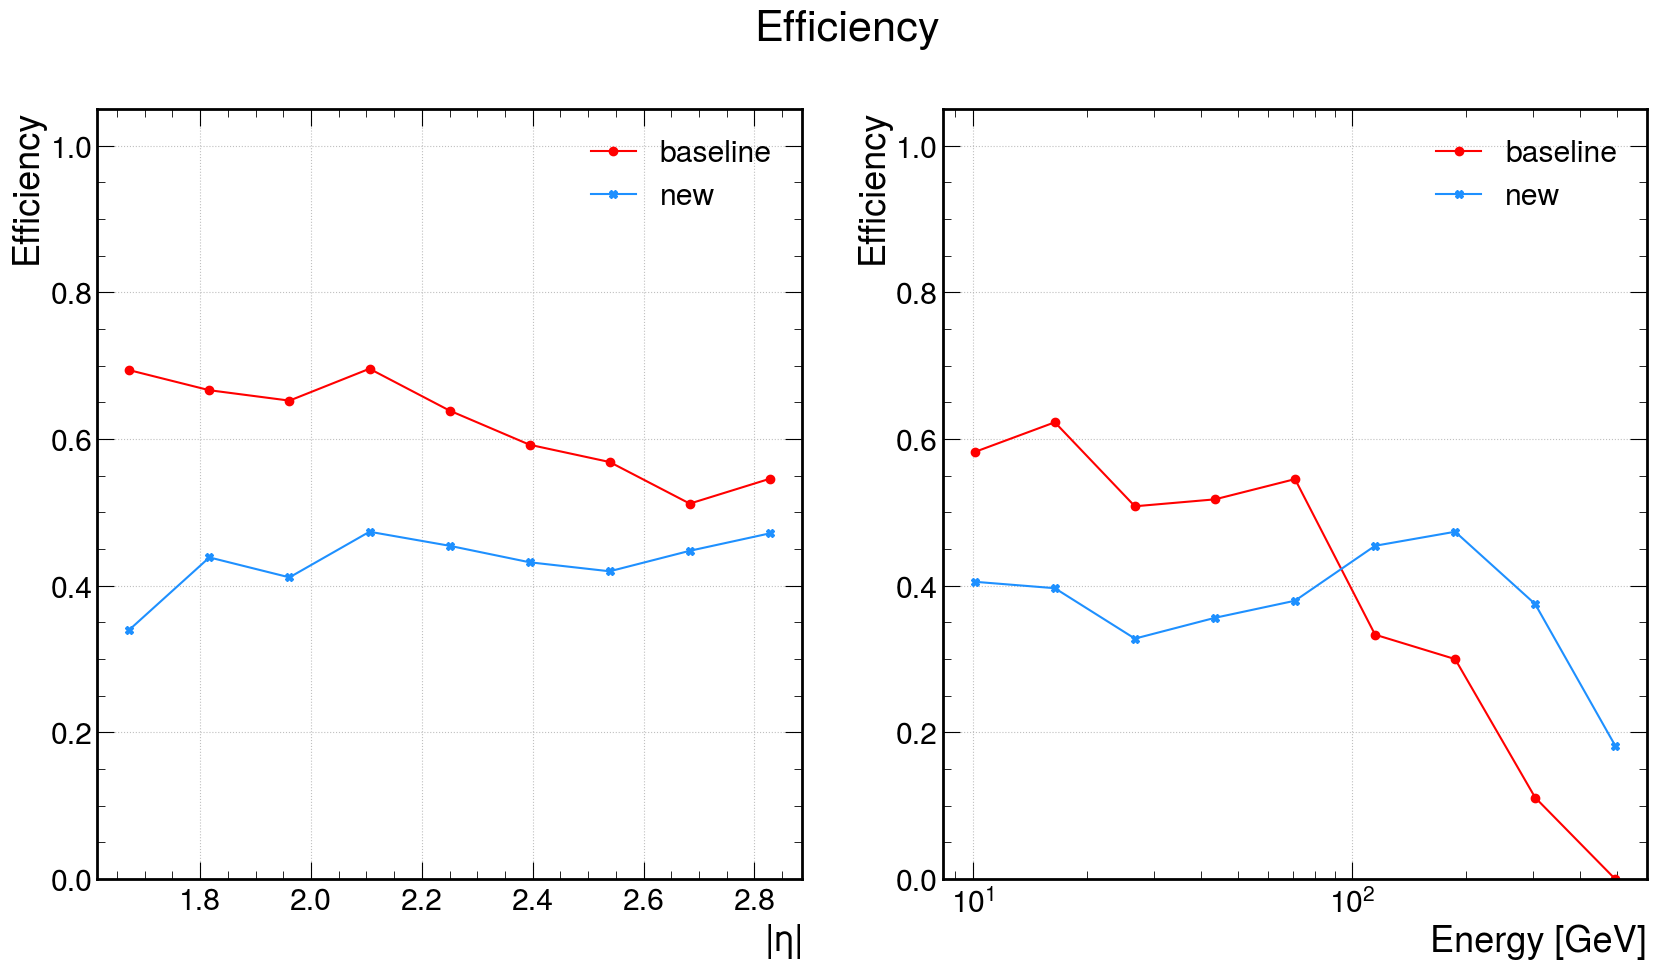

In [61]:
#QCD with QCD training and params
plt.style.use(hep.style.CMS)

plt.figure(figsize=(20, 10))
plt.suptitle("Efficiency")
plt.subplot(1, 2, 1)
plt.plot(eta_centers, effBaseline_eta, marker='o', label = "baseline", color="red")
plt.plot(eta_centers, effLink_eta, marker='X', label = "new", color="dodgerblue")
plt.legend()
plt.xlabel(r'$|\eta|$')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()

plt.subplot(1, 2, 2)
plt.semilogx(pt_centers, effBaseline_pt, marker='o', label = "baseline", color="red")
plt.semilogx(pt_centers, effLink_pt, marker='X', label = "new", color="dodgerblue")
plt.legend()
plt.xlabel(r'Energy [GeV]')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()
plt.show()

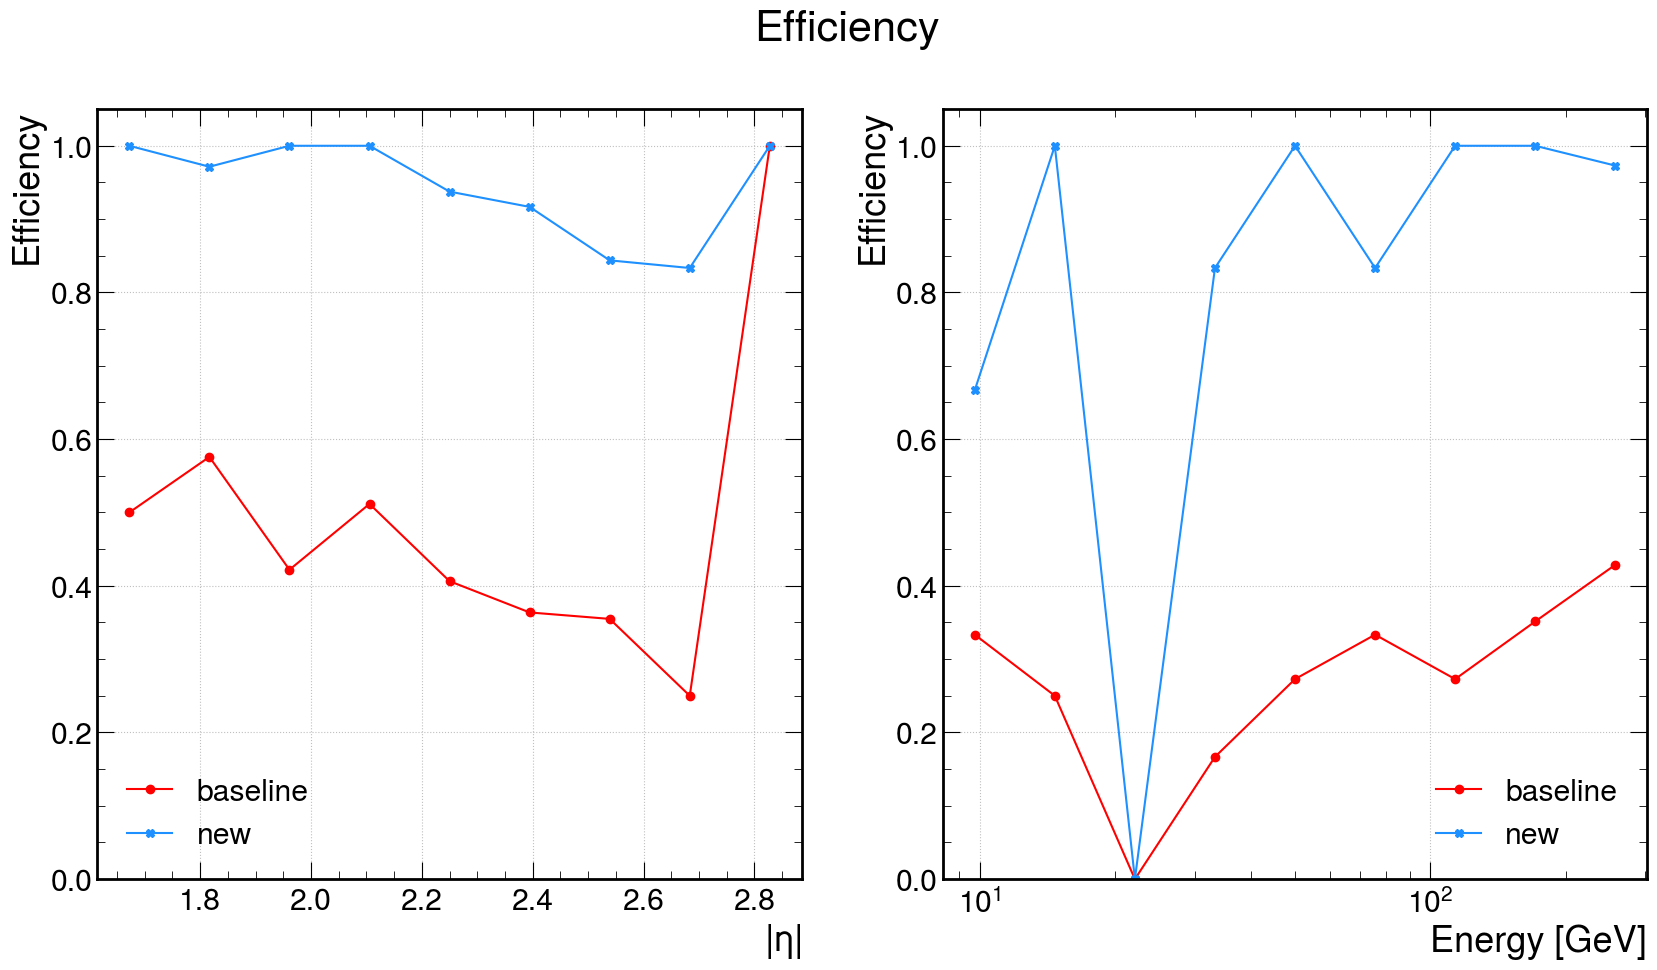

In [175]:
#MULTIPARTICLE
plt.style.use(hep.style.CMS)

plt.figure(figsize=(20, 10))
plt.suptitle("Efficiency")
plt.subplot(1, 2, 1)
plt.plot(eta_centers, effBaseline_eta, marker='o', label = "baseline", color="red")
plt.plot(eta_centers, effLink_eta, marker='X', label = "new", color="dodgerblue")
plt.legend()
plt.xlabel(r'$|\eta|$')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()

plt.subplot(1, 2, 2)
plt.semilogx(pt_centers, effBaseline_pt, marker='o', label = "baseline", color="red")
plt.semilogx(pt_centers, effLink_pt, marker='X', label = "new", color="dodgerblue")
plt.legend()
plt.xlabel(r'Energy [GeV]')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()
plt.show()

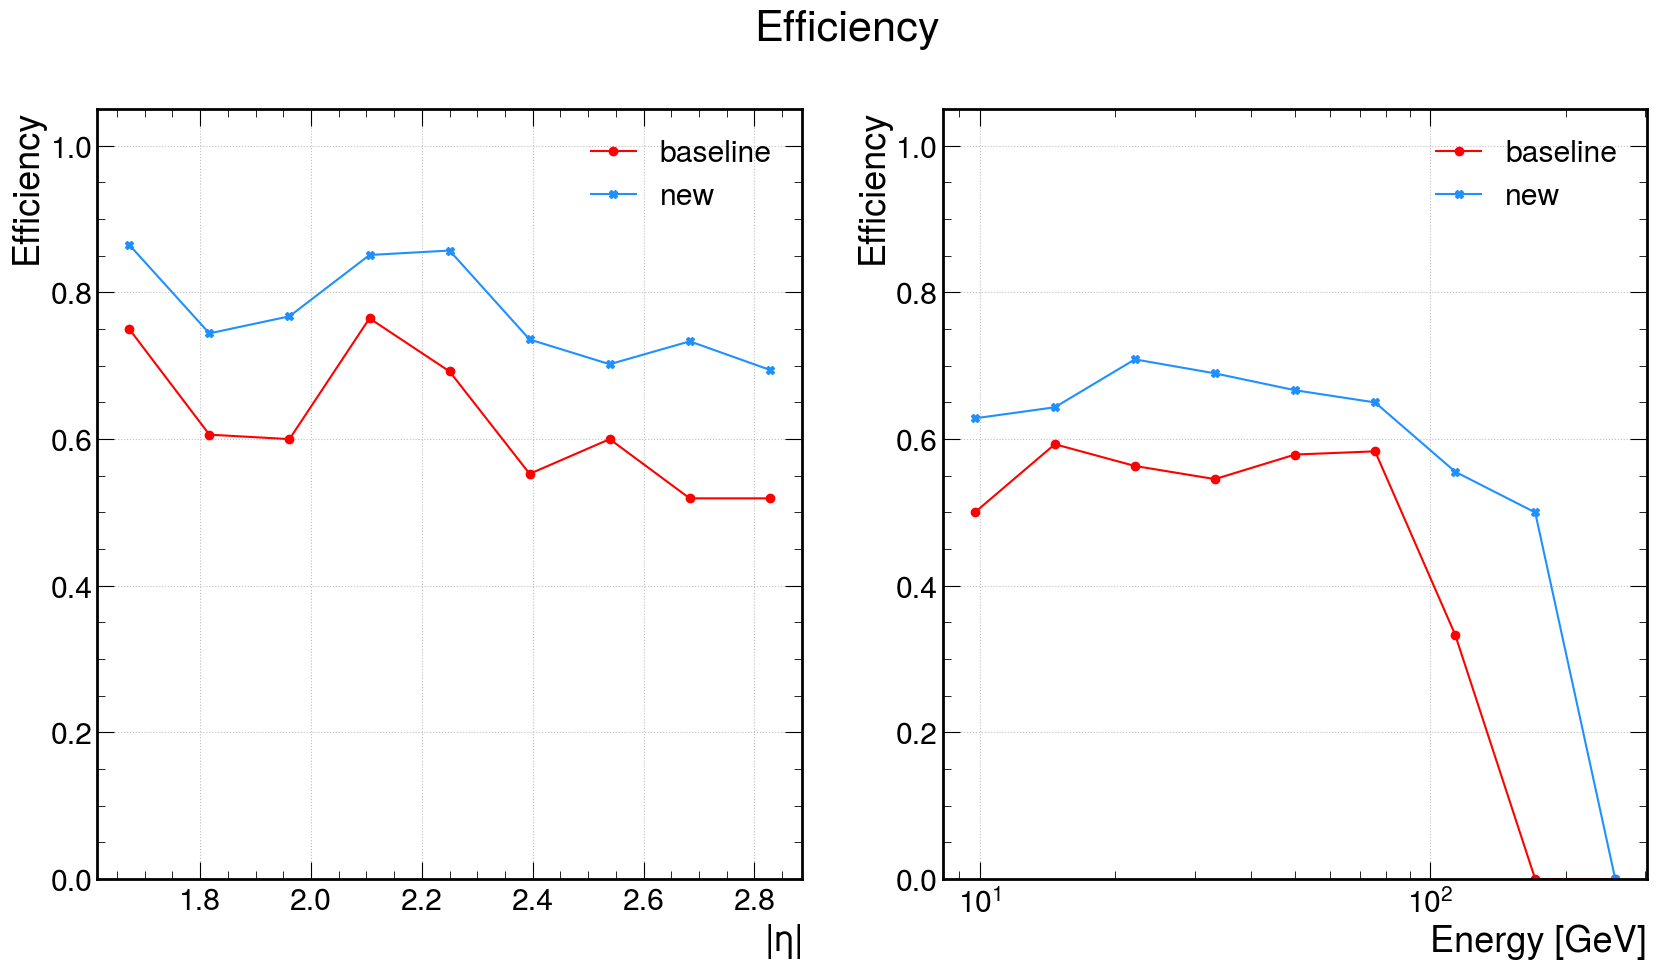

In [206]:
#QCD TRAINED ON MULTIPARTICLE
plt.style.use(hep.style.CMS)

plt.figure(figsize=(20, 10))
plt.suptitle("Efficiency")
plt.subplot(1, 2, 1)
plt.plot(eta_centers, effBaseline_eta, marker='o', label = "baseline", color="red")
plt.plot(eta_centers, effLink_eta, marker='X', label = "new", color="dodgerblue")
plt.legend()
plt.xlabel(r'$|\eta|$')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()

plt.subplot(1, 2, 2)
plt.semilogx(pt_centers, effBaseline_pt, marker='o', label = "baseline", color="red")
plt.semilogx(pt_centers, effLink_pt, marker='X', label = "new", color="dodgerblue")
plt.legend()
plt.xlabel(r'Energy [GeV]')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()
plt.show()

## fake rate

In [66]:
ene_baselineFake = []
eta_baselineFake = []
fake1_baseline =[] # charged vs neutral
fake2_baseline =[] # wrong track

for ev in tqdm(events): #range(100)): #len(simtrackstersSC))):
    cands = candidates[ev]
    candTs = candTracksters[ev]
    tracksEv = tracks[ev]
    stsSCEv = simtrackstersCP[ev]
    
    track_to_cp = {}
    for i in range(len(stsSCEv.trackIdx)):
        if len(stsSCEv.trackIdx[i]) == 0:
            continue
        for itrk in stsSCEv.trackIdx[i]:
            track_to_cp[itrk] = stsSCEv.genJetIdx[i]
    
    for idx in range(len(cands.track_in_candidate)):
        ts_in_cand = cands.tracksters_in_candidate[idx]
        if not (len(ts_in_cand)): continue
        ts_in_cand = ts_in_cand[0]
        tk_in_cand = cands.track_in_candidate[idx]
        
        recoAssScore = associations[ev].ticlCandidate_recoToSim_CP_score[ts_in_cand]
        recoAssEne = associations[ev].ticlCandidate_recoToSim_CP_sharedE[ts_in_cand]
        recoAssIdx = associations[ev].ticlCandidate_recoToSim_CP[ts_in_cand]
        good = np.logical_and(recoAssScore<0.9 , recoAssEne / stsSCEv.raw_energy[recoAssIdx] > 0.5)
        if not np.any(good): continue
        recoAssScore = recoAssScore[good][0]
        recoAssIdx = recoAssIdx[good][0]
        recoAssEne = recoAssEne[good][0]
        
        trkSim = stsSCEv.trackIdx[recoAssIdx]
        if len(trkSim)==0 and tk_in_cand==-1: # true neutral
            fake1_baseline.append(False)
            fake2_baseline.append(False)
        elif len(trkSim)==0 and tk_in_cand!=-1 or len(trkSim)>0 and tk_in_cand==-1:
            # false charged / neutral
            fake1_baseline.append(True)
            fake2_baseline.append(False)
        elif tk_in_cand!=-1 and len(trkSim)>0 :
            true_jet = [track_to_cp[trk] for trk in trkSim]
            if tk_in_cand not in trkSim: # true charged but wrong link
                if tk_in_cand not in track_to_cp:
                    fake1_baseline.append(False)
                    fake2_baseline.append(False)
                elif tk_in_cand in track_to_cp and track_to_cp[tk_in_cand] in true_jet: # but same cp so ok
                    if track_to_cp[tk_in_cand]==-1:
                        fake1_baseline.append(False)
                        fake2_baseline.append(True)
                    else:
                        fake1_baseline.append(False)
                        fake2_baseline.append(False)
                else: # wrong cp
                    fake1_baseline.append(False)
                    fake2_baseline.append(True)
            else: # true charged and true link
                fake1_baseline.append(False)
                fake2_baseline.append(False)
        else:
            print("I missed sth", tk_in_cand, trkSim)
        
        ene_baselineFake.append(candTs.regressed_energy[ts_in_cand])
        eta_baselineFake.append(candTs.barycenter_eta[ts_in_cand])     

100%|██████████| 401/401 [01:12<00:00,  5.53it/s]


In [67]:
eta_baselineFake = np.abs(arr(eta_baselineFake))
ene_baselineFake = arr(ene_baselineFake)
fake1_baseline = arr(fake1_baseline)
fake2_baseline = arr(fake2_baseline)

fake1Baseline_eta = []
fake2Baseline_eta = []
# eta_centers = []

for i in range(len(eta_bins) - 1):
    mask = (eta_baselineFake >= eta_bins[i]) & (eta_baselineFake < eta_bins[i+1])
    
    if np.sum(mask) == 0:
        fake1Baseline_eta.append(0)
        fake2Baseline_eta.append(0)
    else:
        fake1Baseline_eta.append(np.mean(fake1_baseline[mask]))
        fake2Baseline_eta.append(np.mean(fake2_baseline[mask]))
#     eta_centers.append(0.5 * (eta_bins[i] + eta_bins[i+1]))
    
fake1Baseline_pt = []
fake2Baseline_pt = []
# pt_centers = []

for i in range(len(pt_bins) - 1):
    mask = (ene_baselineFake >= pt_bins[i]) & (ene_baselineFake < pt_bins[i+1])

    if np.sum(mask) == 0:
        fake1Baseline_pt.append(0)
        fake2Baseline_pt.append(0)
    else:
        fake1Baseline_pt.append(np.mean(fake1_baseline[mask]))
        fake2Baseline_pt.append(np.mean(fake2_baseline[mask]))
#     pt_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))

In [68]:
ene_fake = []
eta_fake = []
fake1 =[] # charged vs neutral
fake2 =[] # wrong track

for ii, ev in enumerate(tqdm(events)): #range(100)): #len(simtrackstersSC))):
    tsLinks = tracksterLinks[ev]
    tracksEv = tracks[ev]
    stsSCEv = simtrackstersCP[ev]
    
    track_to_cp = {}
    for i in range(len(stsSCEv.trackIdx)):
        if len(stsSCEv.trackIdx[i]) == 0:
            continue
        for itrk in stsSCEv.trackIdx[i]:
            track_to_cp[itrk] = stsSCEv.genJetIdx[i]
    
    # loop over links_ev
    links_ev = all_candidates[ii] #2*ev] + all_candidates[2*ev+1]
    for link in links_ev:
        ts_in_cand = link['tracksters']
        tk_in_cand = link['tracks']
        if len(ts_in_cand)==0: continue
        trkSim = []
        for recoTs in ts_in_cand:
            recoAssScore = associations[ev].ticlTracksterLinks_recoToSim_CP_score[recoTs]
            recoAssEne = associations[ev].ticlTracksterLinks_recoToSim_CP_sharedE[recoTs]
            recoAssIdx = associations[ev].ticlTracksterLinks_recoToSim_CP[recoTs]
            good = np.logical_and(recoAssScore<0.9 , recoAssEne / stsSCEv.raw_energy[recoAssIdx] > 0.5)
            if not np.any(good): continue
            recoAssScore = recoAssScore[good][0]
            recoAssIdx = recoAssIdx[good][0]
            recoAssEne = recoAssEne[good][0]
            if len(stsSCEv.trackIdx[recoAssIdx]):
                trkSim.extend(stsSCEv.trackIdx[recoAssIdx])
        #print(trkSim, tk_in_cand)
        if len(trkSim)==0 and tk_in_cand==None: # true neutral
            fake1.append(False)
            fake2.append(False)
        elif len(trkSim)==0 and tk_in_cand!=None: 
            # false charged / neutral
            fake1.append(True)
            fake2.append(False)
        elif len(trkSim)>0 and tk_in_cand==None:
            trk_pos = []
            for itrk in trkSim:
                trk_tmp = find_track_id(tracksEv.track_id, itrk)
                if trk_tmp != -1: trk_pos.append(trk_tmp)
            if not len(trk_pos):
                fake1.append(False)
                fake2.append(False)
            else:
                pt  = tracksEv.track_hgcal_pt[trk_pos]
                p   = tracksEv.track_p[trk_pos]

                if any(pti > 1 for pti in pt) and any(pi > 2 for pi in p):
                    fake1.append(True)
                    fake2.append(False)
                else:
                    fake1.append(False)
                    fake2.append(False)
        elif tk_in_cand!=None and len(trkSim)>0 :
            if not all(tk in trkSim for tk in tk_in_cand): # true charged but wrong link  -> simtrackstersCP[ev].genJetIdx
                true_jet = [track_to_cp[trk] for trk in trkSim]
                #print(tk_in_cand, trkSim, true_jet)
                isOk = True
                for tk_in_cand1 in tk_in_cand:
                    if tk_in_cand1 not in track_to_cp:
                        #print('reco trk',tracksEv.track_p[find_track_id(tracksEv.track_id, tk_in_cand1)])
                        continue
                    if tk_in_cand1 in track_to_cp and track_to_cp[tk_in_cand1] in true_jet: # but same cp so ok
                        #print("reco jet", track_to_cp[tk_in_cand1])
                        if track_to_cp[tk_in_cand1]==-1:
                            isOk = False
                            break
                    else: # wrong cp
                        isOk = False
                        break
                if isOk:
                    fake1.append(False)
                    fake2.append(False)
                else:
                    fake1.append(False)
                    fake2.append(True)
            else: # true charged and true link
                fake1.append(False)
                fake2.append(False)
        else:
            print("I missed sth", tk_in_cand, trkSim)
        
        ene_fake.append(sum(tsLinks.raw_energy[ts_in_cand]))
        eta_fake.append(np.mean(tsLinks.barycenter_eta[ts_in_cand]))     

100%|██████████| 401/401 [01:14<00:00,  5.35it/s]


In [69]:
eta_fake = np.abs(arr(eta_fake))
ene_fake = arr(ene_fake)
fake1 = arr(fake1)
fake2 = arr(fake2)

fake1_eta = []
fake2_eta = []
eta_centers = []

for i in range(len(eta_bins) - 1):
    mask = (eta_fake >= eta_bins[i]) & (eta_fake < eta_bins[i+1])
    
    if np.sum(mask) == 0:
        fake1_eta.append(0)
        fake2_eta.append(0)
    else:
        fake1_eta.append(np.mean(fake1[mask]))
        fake2_eta.append(np.mean(fake2[mask]))
    eta_centers.append(0.5 * (eta_bins[i] + eta_bins[i+1]))
    
fake1_pt = []
fake2_pt = []
pt_centers = []

for i in range(len(pt_bins) - 1):
    mask = (ene_fake >= pt_bins[i]) & (ene_fake < pt_bins[i+1])

    if np.sum(mask) == 0:
        fake1_pt.append(0)
        fake2_pt.append(0)
    else:
        fake1_pt.append(np.mean(fake1[mask]))
        fake2_pt.append(np.mean(fake2[mask]))
    pt_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))

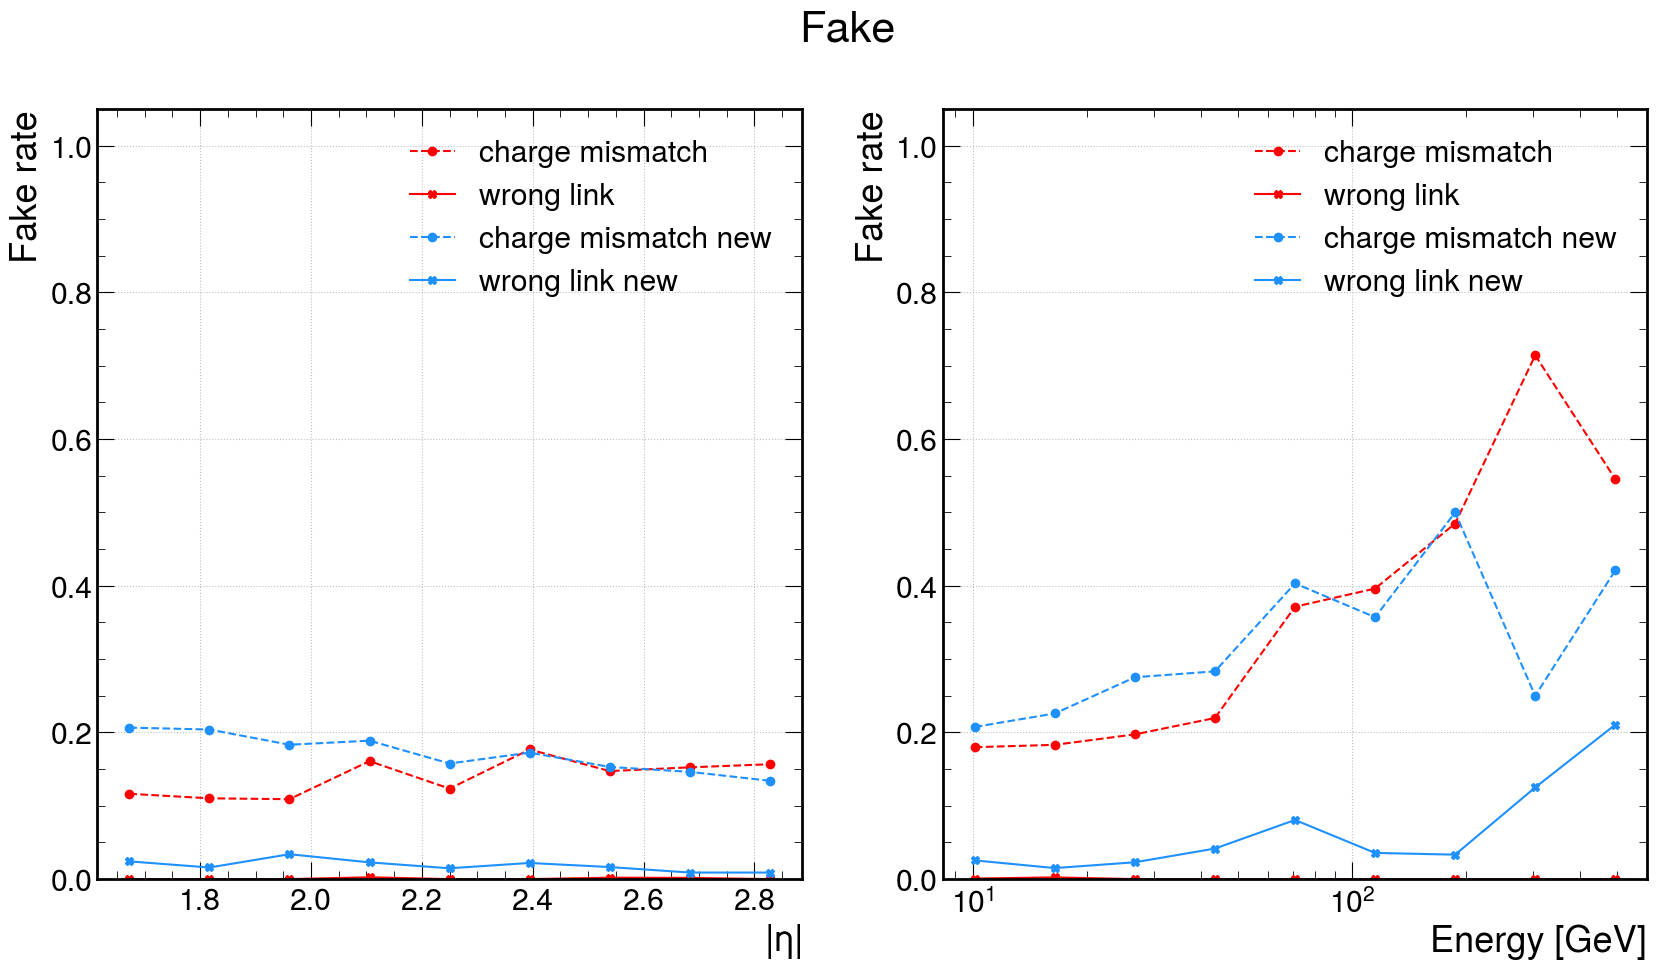

In [70]:
#QCD TRAINED ON QCD
plt.style.use(hep.style.CMS)

plt.figure(figsize=(20, 10))
plt.suptitle("Fake")
plt.subplot(1, 2, 1)
plt.plot(eta_centers, fake1Baseline_eta, marker='o', linestyle="--", label = "charge mismatch", color="red")
plt.plot(eta_centers, fake2Baseline_eta, marker='X', label = "wrong link", color="red") #dodgerblue
plt.plot(eta_centers, fake1_eta, marker='o', linestyle="--", label = "charge mismatch new", color="dodgerblue")
plt.plot(eta_centers, fake2_eta, marker='X', label = "wrong link new", color="dodgerblue") #dodgerblue
plt.legend()
plt.xlabel(r'$|\eta|$')
plt.ylabel('Fake rate')
plt.ylim(0, 1.05)
plt.grid()

plt.subplot(1, 2, 2)
plt.semilogx(pt_centers, fake1Baseline_pt, marker='o', linestyle="--", label = "charge mismatch", color="red")
plt.semilogx(pt_centers, fake2Baseline_pt, marker='X', label = "wrong link", color="red") #dodgerblue
plt.semilogx(pt_centers, fake1_pt, marker='o', linestyle="--", label = "charge mismatch new", color="dodgerblue")
plt.semilogx(pt_centers, fake2_pt, marker='X', label = "wrong link new", color="dodgerblue") #dodgerblue
plt.legend()
plt.xlabel(r'Energy [GeV]')
plt.ylabel('Fake rate')
plt.ylim(0, 1.05)
plt.grid()
plt.show()

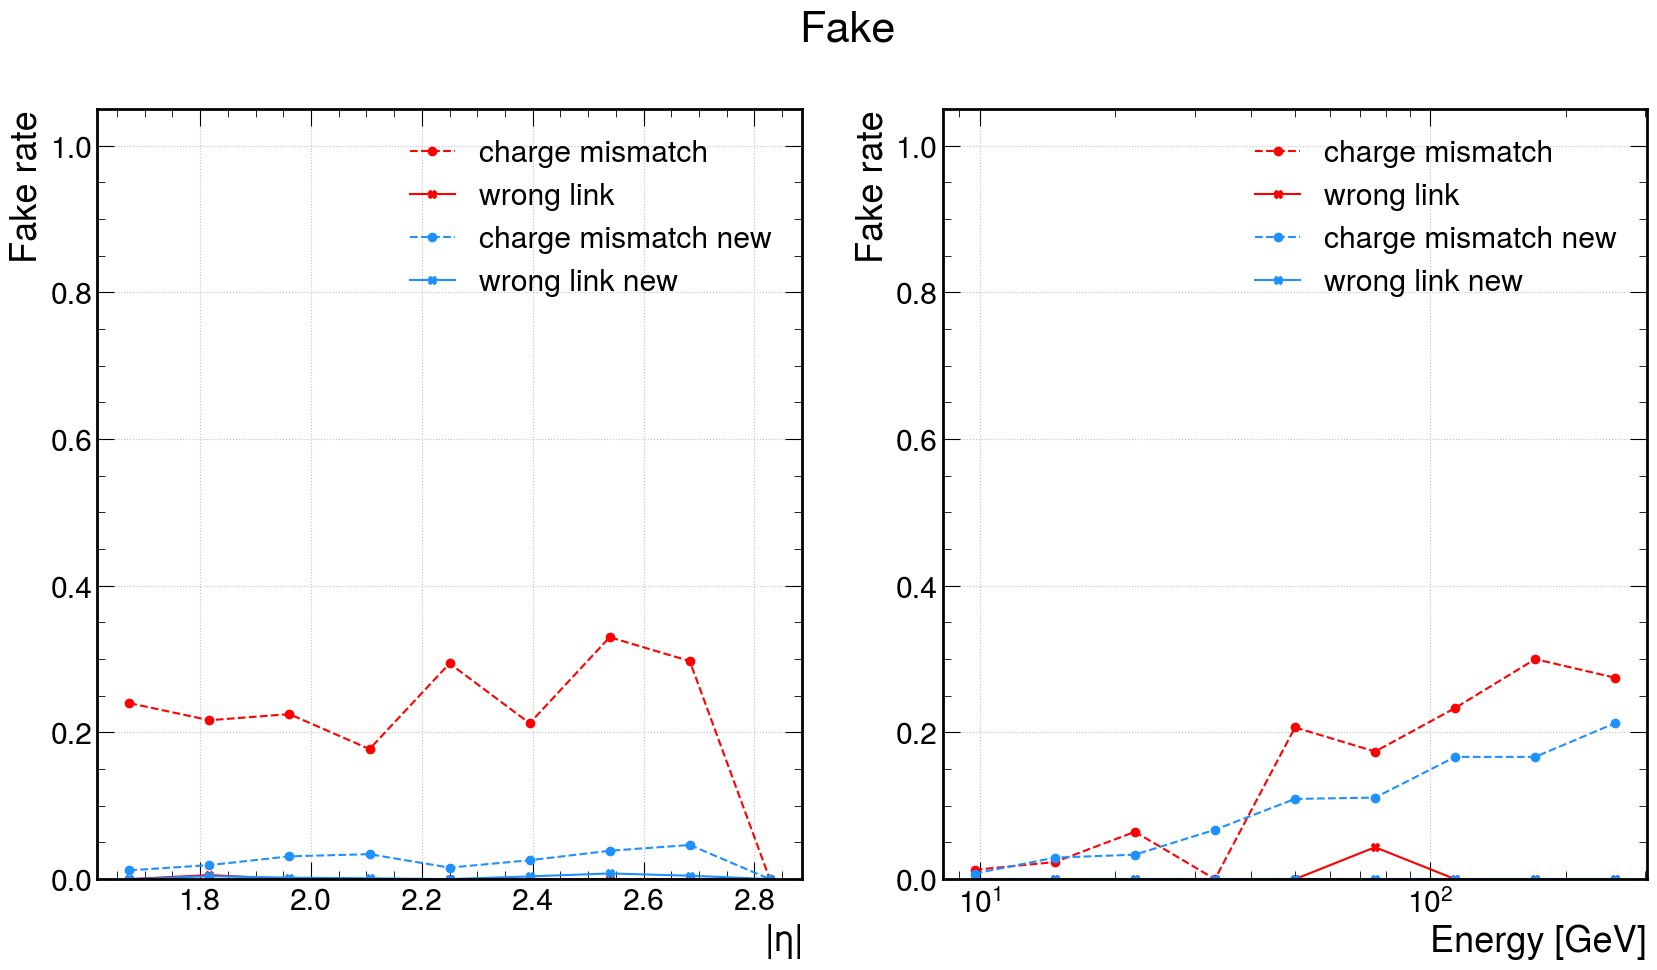

In [180]:

#MULTIPARTICLE
plt.style.use(hep.style.CMS)

plt.figure(figsize=(20, 10))
plt.suptitle("Fake")
plt.subplot(1, 2, 1)
plt.plot(eta_centers, fake1Baseline_eta, marker='o', linestyle="--", label = "charge mismatch", color="red")
plt.plot(eta_centers, fake2Baseline_eta, marker='X', label = "wrong link", color="red") #dodgerblue
plt.plot(eta_centers, fake1_eta, marker='o', linestyle="--", label = "charge mismatch new", color="dodgerblue")
plt.plot(eta_centers, fake2_eta, marker='X', label = "wrong link new", color="dodgerblue") #dodgerblue
plt.legend()
plt.xlabel(r'$|\eta|$')
plt.ylabel('Fake rate')
plt.ylim(0, 1.05)
plt.grid()

plt.subplot(1, 2, 2)
plt.semilogx(pt_centers, fake1Baseline_pt, marker='o', linestyle="--", label = "charge mismatch", color="red")
plt.semilogx(pt_centers, fake2Baseline_pt, marker='X', label = "wrong link", color="red") #dodgerblue
plt.semilogx(pt_centers, fake1_pt, marker='o', linestyle="--", label = "charge mismatch new", color="dodgerblue")
plt.semilogx(pt_centers, fake2_pt, marker='X', label = "wrong link new", color="dodgerblue") #dodgerblue
plt.legend()
plt.xlabel(r'Energy [GeV]')
plt.ylabel('Fake rate')
plt.ylim(0, 1.05)
plt.grid()
plt.show()

# True links

In [90]:
true_links = []

for ev in tqdm(range(1000)): #len(simtrackstersCP))):
    stsCPEv   = simtrackstersCP[ev]
    tracksEv = tracks[ev]
    tsLinksEv = tracksterLinks[ev]
    assEv    = associations[ev]

    true_links_ev = []
    used = []
    
    for idx in prange(len(stsCPEv.trackIdx)):
        # charged / neutral identification
        trackPos = []
        for t in stsCPEv.trackIdx[idx]:
            trk_pos = find_track_id(tracksEv.track_id, t)
            if trk_pos!=-1:
                trackPos.append(int(trk_pos))
        is_charged = len(trackPos)>0
        
        # select good reco tracksters
        maskScore = assEv.ticlTracksterLinks_simToReco_CP_score[idx] < 0.9 # FIXME tracksters with score 0.997 but shEnergy very high
        assocRecoTsIds = assEv.ticlTracksterLinks_simToReco_CP[idx]
        tsEnergy = tsLinksEv.raw_energy[assocRecoTsIds]
        sharedEnergy = assEv.ticlTracksterLinks_simToReco_CP_sharedE[idx]
        maskEnergy = sharedEnergy / tsEnergy > 0.5
        maskIdx = maskScore & maskEnergy
        assIndices = assocRecoTsIds[maskIdx]
        
        if len(assIndices)==0: continue
        if len(set(assIndices).intersection(used)) > 0: print(set(assIndices).intersection(used), assIndices, tsEnergy[maskIdx], true_links_ev)
        used.extend(assIndices)
            
        jet_ids = simtrackstersCP.genJetIdx[ev]
        # ---- store truth info
        true_links_ev.append({
            "genJet": int(jet_ids[idx]),
            "tracks": trackPos if is_charged else [],
            "tracksters": [int(assIdx) for assIdx in assIndices],
            "shEnergy": sharedEnergy[maskIdx]
        })

    true_links.append(true_links_ev)

100%|██████████| 1000/1000 [08:55<00:00,  1.87it/s]


In [92]:
def reco_links_for_sims(true_links_ev, links_ev, min_sh_energy=0.5):
    result = []

    for true_link in true_links_ev:
        trueTss = true_link["tracksters"]
        trueEns = true_link["shEnergy"]
        denom = sum(trueEns)
        matches = []
        
        for i, link in enumerate(links_ev):
            recoTss = link["tracksters"]
            common = [int(x) for x in recoTss if x in trueTss]
            if not common:
                continue

            idx = np.where(np.isin(trueTss, common))[0]
            shEnergy = sum(trueEns[idx]) / denom if denom > 0 else 0.0

            if shEnergy > min_sh_energy:
                matches.append([i, shEnergy])

        result.append(sorted(matches, key=lambda x: x[1], reverse=True))
    return result

def sim_links_for_recos(true_links_ev, links_ev, tsEnergy, min_sh_energy=0.5):
    result = []

    for link in links_ev:
        recoTss = link["tracksters"]
        matches = []

        for i, true_link in enumerate(true_links_ev):
            trueTss = true_link["tracksters"]
            trueEns = true_link["shEnergy"]
            denom = sum(tsEnergy[recoTss])

            common = [int(x) for x in recoTss if x in trueTss]
            if not common:
                continue

            idx = np.where(np.isin(trueTss, common))[0]
            shEnergy = sum(trueEns[idx]) / denom if denom > 0 else 0.0

            if shEnergy > min_sh_energy:
                matches.append([i, shEnergy])

        result.append(sorted(matches, key=lambda x: x[1], reverse=True))
    return result

In [104]:
den_sim  = 0
den_reco = 0

num_eff   = 0  # sim matched with correct track and shEnergy > 0.5
num_pure  = 0  # sim matched to exactly one reco
num_fake  = 0  # reco not matched to any sim (or wrong track)
num_merge = 0  # reco matched to >1 sim

for ev in tqdm(range(100)): #len(simtrackstersCP))):
    true_links_ev = true_links[ev]
    links_ev      = all_candidates[ev]
    trkEnergy_ev  = tracks[ev].track_p
    tsEnergy_ev = tracksterLinks[ev].raw_energy

    # sim -> reco  (efficiency / purity)
    assocSim2Reco = reco_links_for_sims(true_links_ev, links_ev, 0.1)
    #print("s2r", assocSim2Reco)

    for true_link, assoc in zip(true_links_ev, assocSim2Reco):
        if not len(assoc):
            continue  # no reco match at all
        trueTks = true_link["tracks"]   # list of track ids (may be empty)
        trueTss = true_link["tracksters"]
        trueEns = true_link["shEnergy"]

        is_charged = len(trueTks) > 0

        # skip sim objects where no associated track has p > 2 GeV
        if is_charged:
            track_ps = [float(trkEnergy_ev[int(t)]) for t in trueTks]
            if not any(p > 2.0 for p in track_ps):
                continue

        den_sim += 1

        # best reco candidate (highest shEnergy)
        best_reco_idx, best_sh = assoc[0][0], assoc[0][1]
        best_reco = links_ev[best_reco_idx]

        # ---------- track check (charged only) ----------
        track_correct = True
        if is_charged:
            recoTks = best_reco["tracks"]
            if recoTks is None:
                track_correct = False
            else:
                common = [int(x) for x in recoTks if x in trueTks]
                if not common:
                    track_correct = False

        # ---------- efficiency ----------
        # neutral: only shEnergy criterion
        # charged: shEnergy > 0.5 AND at least one track is correct
        if best_sh > 0.5 and (not is_charged or track_correct):
            num_eff += 1

        # ---------- purity ----------
        # pure if this sim object is matched to exactly one reco
        if len(assoc) == 1:
            num_pure += 1

    # reco -> sim  (fake / merge)
    assocReco2Sim = sim_links_for_recos(true_links_ev, links_ev, tsEnergy_ev, 0.1)

    for link, assoc in zip(links_ev, assocReco2Sim):
        recoTks = link["tracks"]
        recoTss = link["tracksters"]

        den_reco += 1

        # fake
        if not len(assoc):
            #num_fake += 1
            continue

        best_sim_idx, best_sh = assoc[0][0], assoc[0][1]
        best_sim = true_links_ev[best_sim_idx]
        trueTrks = best_sim['tracks']

        # also fake if best match has shEnergy < 0.5
        if best_sh < 0.5:
            num_fake += 1
            continue

        # also fake if charged and no track matches the sim genJet
        track_correct = True
        if recoTks is not None and recoTks not in trueTrks:
            track_correct = False
        elif recoTks is None and len(trueTrks) > 0:
            track_ps = [trkEnergy_ev[t] for t in trueTrks]
            if any(p > 2.0 for p in track_ps):
                track_correct = False
        if not track_correct:
            num_fake += 1
        # ---------- merge ----------
        # reco matched to more than one sim object
        if len(assoc) > 1:
            num_merge += 1

print(f"Efficiency : {num_eff / den_sim:.3f}  ({num_eff}/{den_sim})")
print(f"Purity     : {num_pure / den_sim:.3f}  ({num_pure}/{den_sim})")
print(f"Fake rate  : {num_fake / den_reco:.3f}  ({num_fake}/{den_reco})")
print(f"Merge rate : {num_merge / den_reco:.3f}  ({num_merge}/{den_reco})")

100%|██████████| 100/100 [00:17<00:00,  5.75it/s]

Efficiency : 0.777  (953/1227)
Purity     : 0.957  (1174/1227)
Fake rate  : 0.291  (590/2030)
Merge rate : 0.004  (8/2030)


In [94]:
from collections import defaultdict
import numpy as np

def build_truth_maps(true_links):
    track_to_truth = defaultdict(list)
    ts_to_truth = defaultdict(list)

    for tru_idx, tru in enumerate(true_links):
        for trk in tru["tracks"]:
            track_to_truth[int(trk)] = tru_idx
        for ts in tru["tracksters"]:
            ts_to_truth[int(ts)] = tru_idx

    return track_to_truth, ts_to_truth

def validate_reco_candidates(reco_candidates, true_links, trk_energy_map, ts_energy_map):
    track_to_truth, ts_to_truth = build_truth_maps(true_links)
    results = []

    tracks_checks = 0
    tracks_all = 0
    charged_checks = 0
    charged_all = 0
    ts_checks = 0
    ts_all = 0
    for reco_idx, reco in enumerate(reco_candidates):
        reco_tracks = reco["tracks"] if reco["tracks"] is not None else []
        reco_ts = reco["tracksters"]

        if len(reco_tracks)>1:
            for i in range(len(reco_tracks)):
                for j in range(i + 1, len(reco_tracks)):
                    # check if they belong to the same sim
                    trk1 = int(reco_tracks[i])
                    trk2 = int(reco_tracks[j])

                    tru1 = track_to_truth.get(trk1, -1)
                    tru2 = track_to_truth.get(trk2, -2)

                    same_truth = tru1 == tru2
                    same_genjet = False
                    if not same_truth and tru1!=-1 and tru2!=-2:
                        jets1 = true_links[tru1]["genJet"]
                        jets2 = true_links[tru2]["genJet"]
                        same_genjet = jets1 == jets2

                    tracks_all +=1
                    if same_truth or same_genjet:
                        tracks_checks +=1
                    elif not same_truth and same_genjet:
                        tracks_checks +=0.5

        # charged links: track -> trackster      
        for trk in reco_tracks:
            for ts in reco_ts:
                tru_trk = track_to_truth.get(trk, -1)
                tru_ts = ts_to_truth.get(ts, -2)
                direct_match = tru_trk == tru_ts
                jet_match = False
                if not direct_match and tru_trk!=-1 and tru_ts!=-2:
                    jets1 = true_links[tru_trk]["genJet"]
                    jets2 = true_links[tru_ts]["genJet"]
                    jet_match = jets1 == jets2

                charged_all +=1
                if direct_match or jet_match:
                    charged_checks +=1
                elif not direct_match and jet_match:
                    charged_checks +=0.5    

        # trackster-trackster links
        for i in range(len(reco_ts)):
            for j in range(i + 1, len(reco_ts)):
                a, b = reco_ts[i], reco_ts[j]
                tru_a = ts_to_truth.get(a, -1)
                tru_b = ts_to_truth.get(b, -2)
                direct_match = tru_a == tru_b
                jet_match = False
                if not direct_match and tru_a !=-1 and tru_b!=-2:
                    jets1 = true_links[tru_a]["genJet"]
                    jets2 = true_links[tru_b]["genJet"]
                    jet_match = jets1 == jets2
                    
                ts_all +=1
                if direct_match or jet_match:
                    ts_checks +=1
                elif not direct_match and jet_match:
                    ts_checks +=0.5  

        # energy
        if len(reco_tracks):
            energy = sum(float(trk_energy_map[int(t)]) for t in reco_tracks)
            category = "charged"
        else:
            energy = sum(float(ts_energy_map[int(t)]) for t in reco_ts)
            category = "neutral"

    return [tracks_checks / tracks_all if tracks_all!=0 else -1,
            charged_checks / charged_all if charged_all!=0 else -1,
            ts_checks / ts_all if ts_all!=0 else -1]

In [95]:
out = []
for reco_graph, true_graph, ts_energy_map, trk_energy_map in zip(all_candidates, true_links, tracksterLinks.raw_energy, tracks.track_p):
    out.append(validate_reco_candidates(reco_graph, true_graph, trk_energy_map, ts_energy_map))

In [96]:
outT = np.array(out).T
trk = np.mean(outT[0][outT[0]!=-1])
chg = np.mean(outT[1][outT[1]!=-1])
ts= np.mean(outT[2][outT[2]!=-1])
print(trk , chg, ts)

0.2196969696969697 0.7957454369000857 0.42849248987194666


In [97]:
def compute_event_metrics(links_ev, true_links_ev, tsEnergy_ev, trkEnergy_ev):
    den_sim  = 0
    den_reco = 0
    num_eff   = 0
    num_pure  = 0
    num_fake  = 0
    num_merge = 0

    # sim -> reco  (efficiency / purity)
    assocSim2Reco = reco_links_for_sims(true_links_ev, links_ev, 0.1)
    #print("s2r", assocSim2Reco)

    for true_link, assoc in zip(true_links_ev, assocSim2Reco):
        if not len(assoc):
            continue  # no reco match at all
        trueTks = true_link["tracks"]   # list of track ids (may be empty)
        trueTss = true_link["tracksters"]
        trueEns = true_link["shEnergy"]

        is_charged = len(trueTks) > 0

        # skip sim objects where no associated track has p > 2 GeV
        if is_charged:
            track_ps = [float(trkEnergy_ev[int(t)]) for t in trueTks]
            if not any(p > 2.0 for p in track_ps):
                continue

        den_sim += 1

        # best reco candidate (highest shEnergy)
        best_reco_idx, best_sh = assoc[0][0], assoc[0][1]
        best_reco = links_ev[best_reco_idx]

        # ---------- track check (charged only) ----------
        track_correct = True
        if is_charged:
            recoTks = best_reco["tracks"]
            if recoTks is None:
                track_correct = False
            else:
                common = [int(x) for x in recoTks if x in trueTks]
                if not common:
                    track_correct = False

        # ---------- efficiency ----------
        # neutral: only shEnergy criterion
        # charged: shEnergy > 0.5 AND at least one track is correct
        if best_sh > 0.5 and (not is_charged or track_correct):
            num_eff += 1

        # ---------- purity ----------
        # pure if this sim object is matched to exactly one reco
        if len(assoc) == 1:
            num_pure += 1

    # reco -> sim  (fake / merge)
    assocReco2Sim = sim_links_for_recos(true_links_ev, links_ev, tsEnergy_ev, 0.1)
    #print("r2s", assocReco2Sim)

    for link, assoc in zip(links_ev, assocReco2Sim):
        recoTks = link["tracks"]
        recoTss = link["tracksters"]

        den_reco += 1

        # fake                                                                                                                                                                               
        if not len(assoc):
            num_fake += 1
            continue

        best_sim_idx, best_sh = assoc[0][0], assoc[0][1]
        best_sim = true_links_ev[best_sim_idx]
        trueTrks = best_sim['tracks']

        # also fake if best match has shEnergy < 0.5
        if best_sh < 0.5:
            num_fake += 1
            continue

        # also fake if charged and no track matches the sim genJet
        track_correct = True
        if recoTks is not None and recoTks not in trueTrks:
            track_correct = False
        elif recoTks is None and len(trueTrks) > 0:
            track_ps = [trkEnergy_ev[t] for t in trueTrks]
            if any(p > 2.0 for p in track_ps):
                track_correct = False
        if not track_correct:
            num_fake += 1
        # ---------- merge ----------
        # reco matched to more than one sim object
        if len(assoc) > 1:
            num_merge += 1
    eff = num_eff/den_sim if den_sim != 0 else -1
    pure = num_pure/den_sim if den_sim != 0 else -1
    fake = num_fake/den_reco if den_reco != 0 else -1
    merge = num_merge/den_reco if den_reco != 0 else -1
    return [eff, pure, fake, merge]

def compute_graph_metrics_all_events(reco_graphs, true_graphs, ts_energy_maps, trk_energy_maps):

    out = []
    for reco_graph, true_graph, ts_energy_map, trk_energy in zip(reco_graphs, true_graphs, ts_energy_maps, trk_energy_maps):
        out.append(compute_event_metrics(reco_graph, true_graph, ts_energy_map, trk_energy))

    outT = np.array(out).T
    avg = {
        'eff': np.mean(outT[0][outT[0]!=-1]),
        'merge': np.mean(outT[3][outT[3]!=-1]),
        'fake': np.mean(outT[2][outT[2]!=-1]),
        'purity': np.mean(outT[1][outT[1]!=-1]),
    }
    return avg

In [99]:
compute_graph_metrics_all_events(all_candidates[:1000], true_links[:1000], tracksterLinks[:1000].raw_energy, tracks[:1000].track_p)

{'eff': np.float64(0.7597109478776572),
 'merge': np.float64(0.0022814434685273412),
 'fake': np.float64(0.49557663328702806),
 'purity': np.float64(0.951087435916221)}

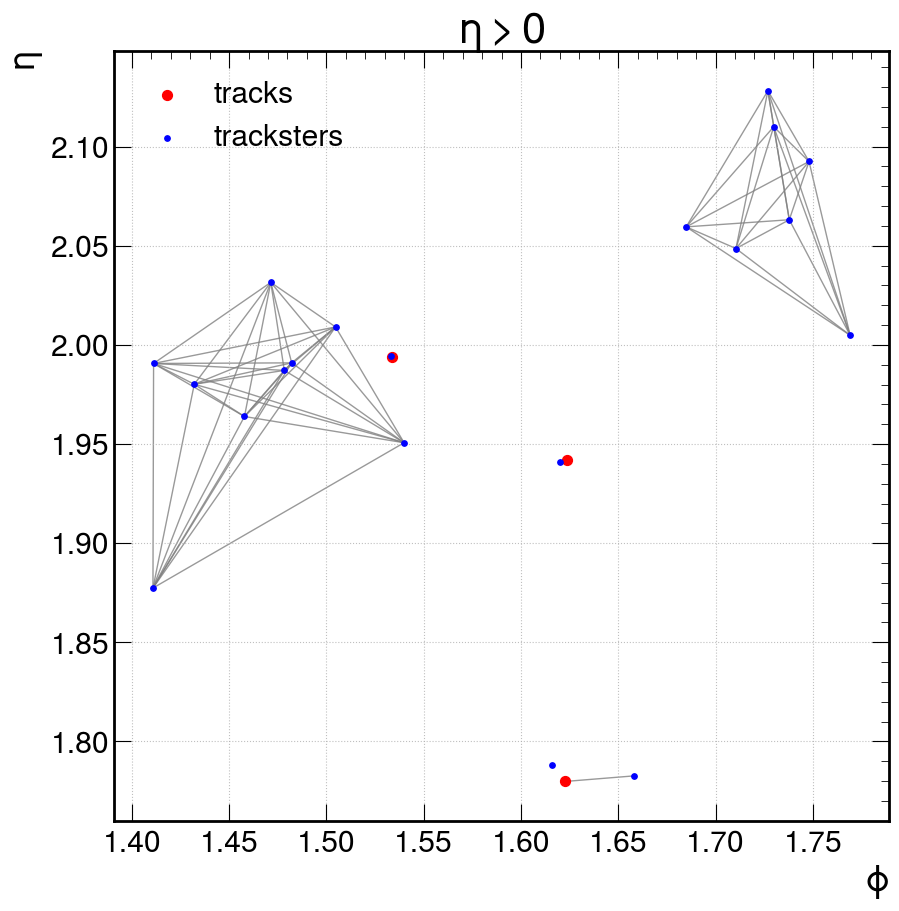

In [358]:
# Build positions
pos = {
    n: (d["phi"], d["eta"])
    for n, d in g0Truth.nodes(data=True)
    if "phi" in d and "eta" in d
}

# Split nodes by type and eta sign
trk_pos = [n for n, d in g0Truth.nodes(data=True) if d["node_type"]=="track"]
ts_pos  = [n for n, d in g0Truth.nodes(data=True) if d["node_type"]=="trackster"]

etas = [v[1] for v in pos.values()]
phis = [v[0] for v in pos.values()]
phi_min, phi_max = min(phis), max(phis)
eta_min, eta_max = min(etas), max(etas)

plt.figure()
ax1 = plt.subplot(1,1,1)
nx.draw_networkx_nodes(g0Truth, pos, nodelist=trk_pos, node_color="red", node_size=50, ax=ax1, label="tracks")
nx.draw_networkx_nodes(g0Truth, pos, nodelist=ts_pos, node_color="blue", node_size=15, ax=ax1, label="tracksters")
nx.draw_networkx_edges(g0Truth, pos, edgelist=[e for e in g0Truth.edges], # if e[0] in trk_pos or e[1] in ts_pos],
                       edge_color="gray", alpha=0.8, ax=ax1, width=1, arrows=False)

ax1.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
ax1.set_xlim(phi_min- 0.02, phi_max+0.02)
ax1.set_ylim(eta_min- 0.02, eta_max+0.02)
# ax1.set_xticks(np.linspace(phi_min, phi_max, 4))
# #ax1.set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
# ax1.set_yticks(np.linspace(eta_min, eta_max, 4))
ax1.set_xlabel(r"$\phi$")
ax1.set_ylabel(r"$\eta$")
ax1.set_title(r"$\eta > 0$")
ax1.legend()
ax1.grid(True)
plt.show()

In [45]:
def pretty_print(links):
    string = ""
    for l in links:
        string += "\n- track: "+ str(l['track_id']) + ", tracksters: "+ str(l['reco_ts'])+", CP: " + str(l['cp_id'])
    return string

In [ ]:
for ev in range(len(true_links)):
    print(f"\n--- ev {ev} ---")
    print("true_links: ", pretty_print(true_links[ev]))
    true_tracks = np.array([l['track_id'] for l in true_links[ev] if l['track_id'] is not None ]).flatten()
    print("true_links extra: ", pretty_print(true_links_extra[ev]))
    true_tracks_extra = np.array([l['track_id'] for l in true_links[ev] if l['track_id'] is not None ]).flatten()
    
    print("reco:")
    for endcap in [all_candidates[2*ev], all_candidates[2*ev+1]]:
        for cand in endcap:
            if cand['track'] is None:
                print("- neutral: ", cand["tracksters"])
            else: #if cand['track'] in true_tracks or cand['track'] in true_tracks_extra: #uncomment this if running with PU
                print("- charged: ", cand)

In [25]:
# # check that tracksters are used only once
# for c_ev in all_candidates:
#     all_ts = []
#     for c in c_ev:
#         all_ts.extend(c["tracksters"])
#     assert(len(all_ts) == len(set(all_ts)))

# full validation new

In [405]:
effTight_flags = []
effLoose_flags = []
purity_flags = []
eta_vals = []
pt_vals = []

wrong = []
for ev in prange(len(true_links)):

    links_ev = all_candidates[2*ev] + all_candidates[2*ev+1] #all_links_no_score[ev]
    tracks_links_ev = np.array([l['track'] if l['track'] is not None else -1 for l in links_ev])
    tracksEv = tracks[ev]
    for true_link in true_links[ev]:
        itrk = true_link['track_id']
        true_ts_list = true_link['reco_ts']
        if not len(true_ts_list) or itrk is None: continue #only charged for now
        trk_pos = find_track_id(tracksEv.track_id, itrk) 
        if trk_pos == -1:
            continue
        
        # Track kinematics
        eta = tracksEv.track_hgcal_eta[trk_pos]
        pt  = tracksEv.track_hgcal_pt[trk_pos]
        p  = tracksEv.track_p[trk_pos]
        
        if pt < 1 or p < 2: continue
        
        # Was this track linked at all?
        if itrk[0] not in tracks_links_ev: 
            effTight_flags.append(False)
            effLoose_flags.append(False)
            purity_flags.append(False)
            eta_vals.append(eta)
            pt_vals.append(pt)
            wrong.append((ev, itrk))
            continue
            
        cand_pos = np.where(np.array(tracks_links_ev)==itrk[0])[0][0]
        reco_ts = links_ev[cand_pos]['tracksters']
        
        # True if ANY true trackster is found
        matched_loose = any(its in reco_ts for its in true_ts_list)
        matched_tight = all(its in reco_ts for its in true_ts_list)
        pure = all(its in true_ts_list for its in reco_ts)
        
        if matched_loose==False:
            wrong.append((ev, itrk))
        
        effTight_flags.append(matched_tight)
        effLoose_flags.append(matched_loose)
        purity_flags.append(pure)
        eta_vals.append(eta)
        pt_vals.append(pt)
    
# print(effTight_flags)
effTight_flags = arr(effTight_flags)
effLoose_flags = arr(effLoose_flags)
purity_flags = arr(purity_flags)
eta_vals = arr(eta_vals)
pt_vals = arr(pt_vals)

In [28]:
effTight = np.mean(arr(effTight_flags))                                                                                                                                                      
effLoose = np.mean(arr(effLoose_flags))
purity = np.mean(arr(purity_flags))

print(str(PT) + " " + str(ETA) + " " + str(effTight) + " " + str(effLoose) + " " + str(purity))

100 1.7 0.46269063180827885 0.8970588235294118 0.8537581699346405


In [57]:
eta_bins = np.linspace(1.6, 2.9 ,10)

eta_vals = np.abs(np.array(eta_vals))

effTight_eta = []
effLoose_eta = []
purity_eta = []
eta_centers = []

for i in range(len(eta_bins) - 1):
    mask = (eta_vals >= eta_bins[i]) & (eta_vals < eta_bins[i+1])

    if np.sum(mask) == 0:
        effTight_eta.append(0)
        effLoose_eta.append(0)
        purity_eta.append(0)
    else:
        effTight_eta.append(np.mean(effTight_flags[mask]))
        effLoose_eta.append(np.mean(effLoose_flags[mask]))
        purity_eta.append(np.mean(purity_flags[mask]))

    eta_centers.append(0.5 * (eta_bins[i] + eta_bins[i+1]))

In [58]:
pt_bins = np.linspace(1, 100 ,10)

pt_vals = np.array(pt_vals)

effTight_pt = []
effLoose_pt = []
purity_pt = []
pt_centers = []

for i in range(len(pt_bins) - 1):
    mask = (pt_vals >= pt_bins[i]) & (pt_vals < pt_bins[i+1])

    if np.sum(mask) == 0:
        effTight_pt.append(0)
        effLoose_pt.append(0)
        purity_pt.append(0)
    else:
        effTight_pt.append(np.mean(effTight_flags[mask]))
        effLoose_pt.append(np.mean(effLoose_flags[mask]))
        purity_pt.append(np.mean(purity_flags[mask]))

    pt_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))

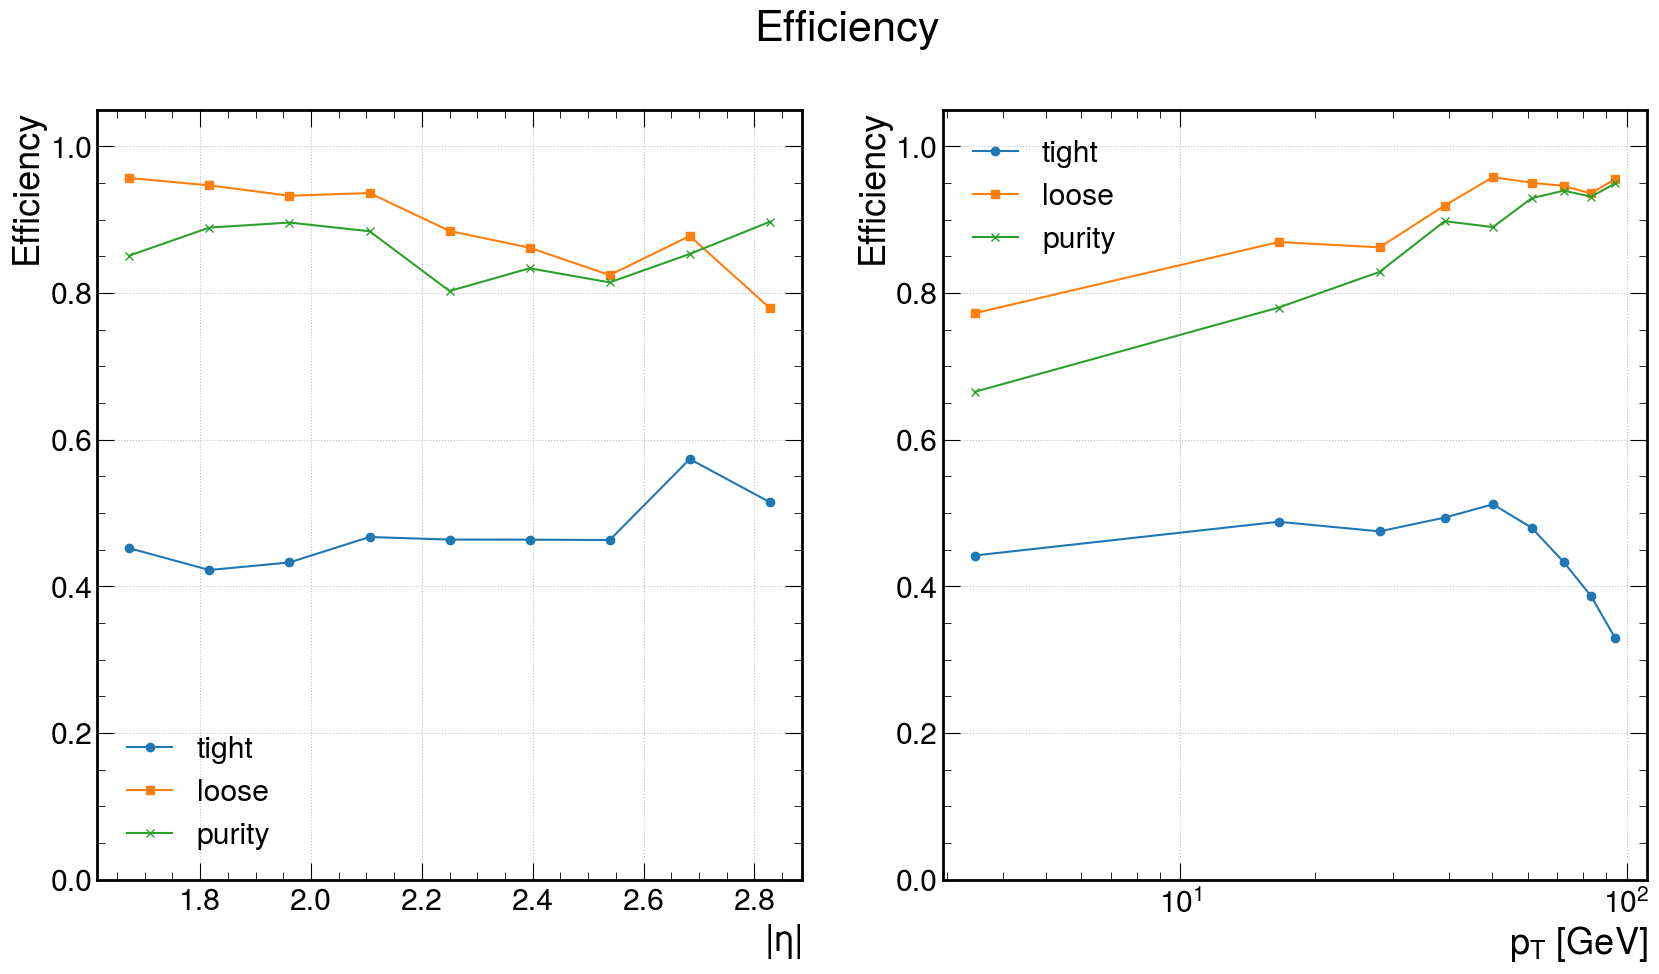

In [34]:
plt.style.use(hep.style.CMS)

plt.figure(figsize=(20, 10))
plt.suptitle("Efficiency")
plt.subplot(1, 2, 1)
plt.plot(eta_centers, effTight_eta, marker='o', label = "tight")
plt.plot(eta_centers, effLoose_eta, marker='s', label = "loose")
plt.plot(eta_centers, purity_eta, marker='x', label = "purity")
plt.legend()
plt.xlabel(r'$|\eta|$')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()

plt.subplot(1, 2, 2)
plt.semilogx(pt_centers, effTight_pt, marker='o', label = "tight")
plt.semilogx(pt_centers, effLoose_pt, marker='s', label = "loose")
plt.semilogx(pt_centers, purity_pt, marker='x', label = "purity")
plt.legend()
plt.xlabel(r'$p_T$ [GeV]')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()
plt.show()

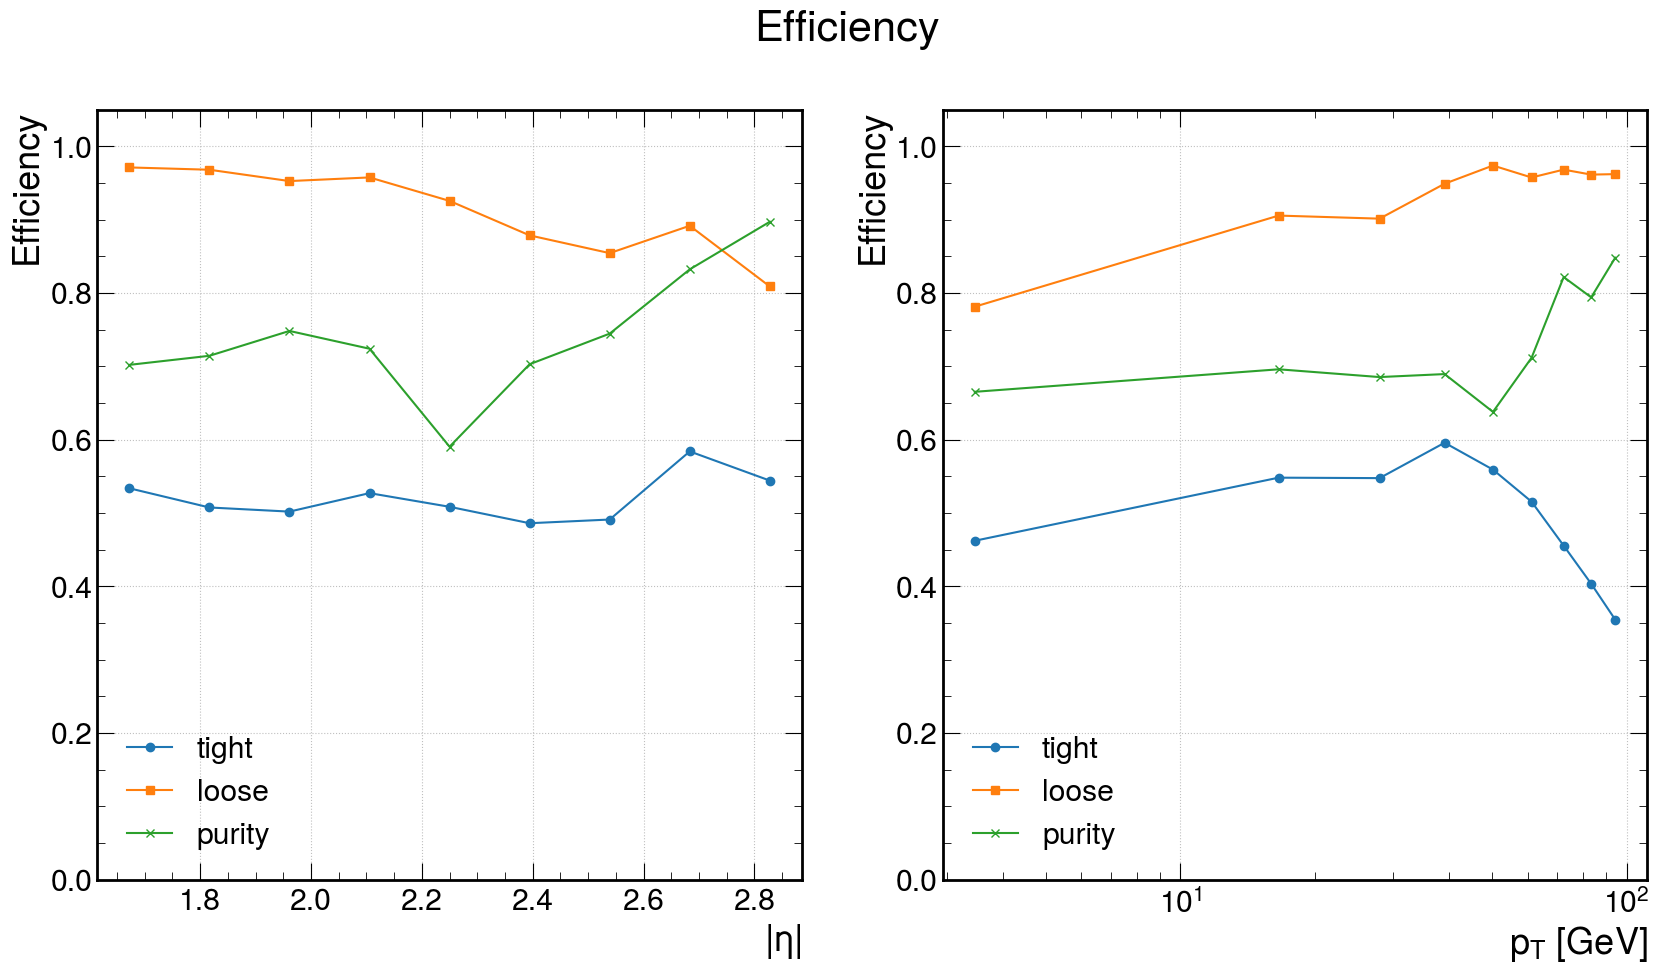

In [239]:
#dR=0.1
plt.style.use(hep.style.CMS)

plt.figure(figsize=(20, 10))
plt.suptitle("Efficiency")
plt.subplot(1, 2, 1)
plt.plot(eta_centers, effTight_eta, marker='o', label = "tight")
plt.plot(eta_centers, effLoose_eta, marker='s', label = "loose")
plt.plot(eta_centers, purity_eta, marker='x', label = "purity")
plt.legend()
plt.xlabel(r'$|\eta|$')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()

plt.subplot(1, 2, 2)
plt.semilogx(pt_centers, effTight_pt, marker='o', label = "tight")
plt.semilogx(pt_centers, effLoose_pt, marker='s', label = "loose")
plt.semilogx(pt_centers, purity_pt, marker='x', label = "purity")
plt.legend()
plt.xlabel(r'$p_T$ [GeV]')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()
plt.show()

## neutrals

In [54]:
def find_in_irregural_array(array, match):
    for i, el in enumerate(array):
        if len(el) == 0: continue
        if match in el:
            return i
    return -1

In [68]:
eff_flags = []
ene_vals = []
eta_vals = []

for ev in prange(len(true_links)):

    links_ev = all_candidates[2*ev] + all_candidates[2*ev+1] #all_links_no_score[ev]
    ts_links_ev = [l['tracksters'] for l in links_ev]
    tracksEv = tracks[ev]
    ts_to_cp = {}
    for true_link in true_links[ev]:
        for ts in true_link['reco_ts']:
            ts_to_cp[ts] = true_link['cp_id']
            
    for true_link in true_links[ev]:
        cpIdx = true_link['cp_id']
        itrk = true_link['track_id']
        true_ts_list = true_link['reco_ts']
        if not len(true_ts_list) or itrk is not None: continue #only neutral
        
        correct = True
        for true_ts in true_ts_list:
            if true_ts not in ak.flatten(ts_links_ev):
                continue
            cand_pos = find_in_irregural_array(ts_links_ev, true_ts)
            reco_ts = links_ev[cand_pos]['tracksters']
            if len(reco_ts)==1:
                correct = True
            else:
                for ts in reco_ts:
                    if ts in ts_to_cp and ts_to_cp[ts] != cpIdx:
                        correct=False
                        break
        if correct:
            eff_flags.append(True)
        else:
            eff_flags.append(False)
        
        eta_vals.append(stsCPEv.barycenter_eta[cpIdx])
        ene_vals.append(stsCPEv.regressed_energy[cpIdx])

    
# print(effTight_flags)
eff_flags = arr(eff_flags)
eta_vals = arr(eta_vals)
ene_vals = arr(ene_vals)

In [70]:
eta_bins = np.linspace(1.6, 2.9 ,10)
pt_bins = np.logspace(0.9 , 2.7 ,10) #this is energy not pt

In [71]:
effLink_eta = []
eta_centers = []

for i in range(len(eta_bins) - 1):
    mask = (eta_vals >= eta_bins[i]) & (eta_vals < eta_bins[i+1])
    
    if np.sum(mask) == 0:
        effLink_eta.append(0)
    else:
        effLink_eta.append(np.mean(eff_flags[mask]))
    eta_centers.append(0.5 * (eta_bins[i] + eta_bins[i+1]))
    
effLink_pt = []
pt_centers = []

for i in range(len(pt_bins) - 1):
    mask = (ene_vals >= pt_bins[i]) & (ene_vals < pt_bins[i+1])

    if np.sum(mask) == 0:
        effLink_pt.append(0)
    else:
        effLink_pt.append(np.mean(eff_flags[mask]))
    pt_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))

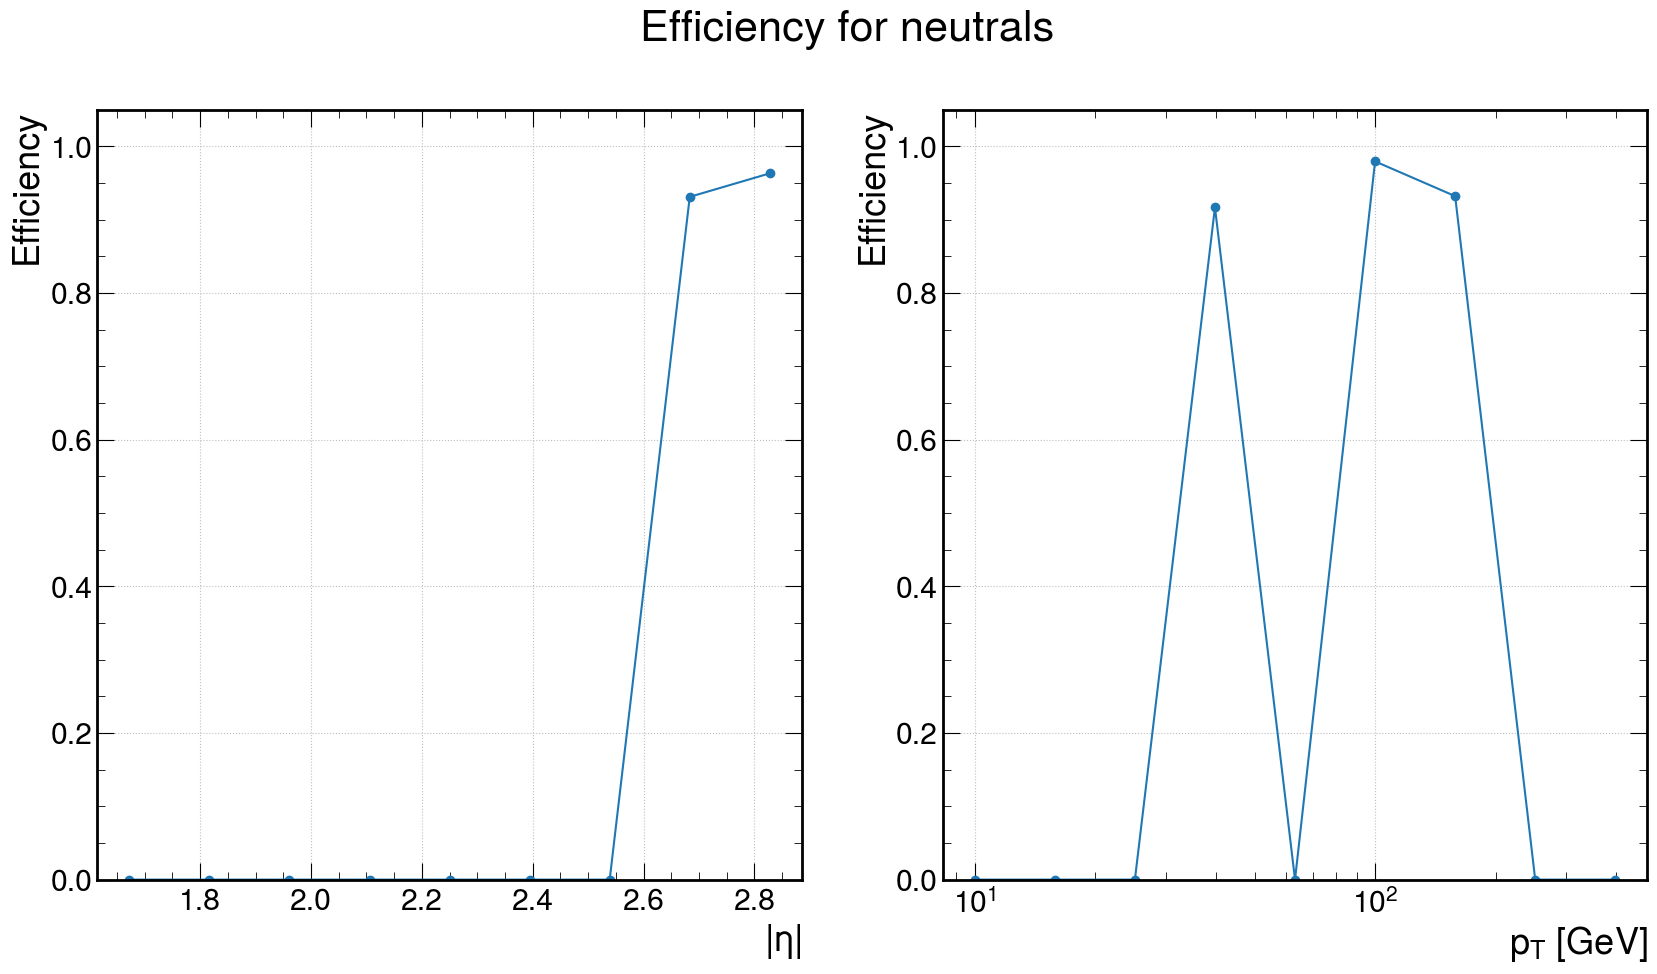

In [72]:
#dR=0.1
plt.style.use(hep.style.CMS)

plt.figure(figsize=(20, 10))
plt.suptitle("Efficiency for neutrals")
plt.subplot(1, 2, 1)
plt.plot(eta_centers, effLink_eta, marker='o', label = "tight")
# plt.legend()
plt.xlabel(r'$|\eta|$')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()

plt.subplot(1, 2, 2)
plt.semilogx(pt_centers, effLink_pt, marker='o', label = "tight")
# plt.legend()
plt.xlabel(r'$p_T$ [GeV]')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()
plt.show()

## debug missing links

In [49]:
def debug_missing_links_flow(ev, trk_id):
    #trk_id = trk_id[0]
    # find the tuple for this track
    correct_ts_ids = None
    for true_link in true_links[ev]:
        tid = true_link['track_id'][0] if true_link['track_id'] is not None else -1 
        ts_arr = true_link['reco_ts']
        cp_id = true_link['cp_id']
        if tid == trk_id:
            correct_ts_ids = np.asarray(ts_arr)  # convert Awkward Array to numpy
            break

    if correct_ts_ids is None:
        print(f"TYPE 1: Track {trk_id} not found in true_links for event {ev}")
        return

    links_ev = all_candidates[2*ev] + all_candidates[2*ev+1]
    ts_links_ev = []
    for l in links_ev:
        ts_links_ev.append(l['tracksters'])

    print(f"\nEvent {ev}, track {trk_id}")
    print(f"Correct TS IDs: {correct_ts_ids}")

    for correct_ts in correct_ts_ids:
        if correct_ts not in ak.flatten(ts_links_ev):
            print(f"  Correct TS {correct_ts} not linked to anything nor neutral")
            continue

        # check if linked elsewhere
        try:
            cand_idx = ak.where(ak.sum(ak.Array(ts_links_ev)==correct_ts, axis=1)==1)[0][0]
        except:
            print(f"    TYPE 2: Correct TS {correct_ts} not linked")
            print(ts_links_ev, correct_ts)
            continue

        tk_linked = links_ev[cand_idx]['track']
        if tk_linked==trk_id:
            print("    TS {correct_ts} linked correctly")
            continue
        elif tk_linked==None:
            print(f"    TYPE 3: Correct TS {correct_ts} not linked to a track")
            continue
        else:
            print(f"    TYPE 4: Correct TS {correct_ts} wrongly linked to track {tk_linked}")

        # get pT/P for correct and wrongly linked tracks
#         print(tracks[ev].track_id, trk_id)
        pos_correct = np.where(tracks[ev].track_id == trk_id)[0][0]
        Pt_correct = tracks[ev].track_hgcal_pt[pos_correct]
        P_correct = tracks[ev].track_p[pos_correct]

        pos_wrong = np.where(tracks[ev].track_id == tk_linked)[0][0]
        Pt_wrong = tracks[ev].track_hgcal_pt[pos_wrong]
        P_wrong = tracks[ev].track_p[pos_wrong]

        print(f"      Correct track Pt: {Pt_correct:.3f}, Wrongly linked track Pt: {Pt_wrong:.3f}")
        
        for true_link in true_links[ev]:
            tid_wrong = true_link['track_id'][0] if true_link['track_id'] is not None else -1 
            cp_id_wrong = true_link['cp_id']
            if tid_wrong == tk_linked:
                print(f"      Correct track CP: {cp_id}, Wrongly linked track CP: {cp_id_wrong}")
                break

In [50]:
# example: check ev=19, track 4017
for ev, trk in wrong:
    debug_missing_links_flow(ev=ev, trk_id=trk)


Event 1, track 0
Correct TS IDs: [0]
    TYPE 3: Correct TS 0 not linked to a track

Event 7, track 0
Correct TS IDs: [0]
    TYPE 4: Correct TS 0 wrongly linked to track 1
      Correct track Pt: 10.555, Wrongly linked track Pt: 9.731
      Correct track CP: 1, Wrongly linked track CP: 2

Event 12, track 3
Correct TS IDs: [0]
    TYPE 3: Correct TS 0 not linked to a track

Event 16, track 1
Correct TS IDs: [ 0 11]
    TYPE 3: Correct TS 0 not linked to a track
    TYPE 3: Correct TS 11 not linked to a track

Event 17, track 1
Correct TS IDs: [ 0 16 18]
    TYPE 4: Correct TS 0 wrongly linked to track 0
      Correct track Pt: 9.261, Wrongly linked track Pt: 14.849
      Correct track CP: 2, Wrongly linked track CP: 5
    TYPE 4: Correct TS 16 wrongly linked to track 0
      Correct track Pt: 9.261, Wrongly linked track Pt: 14.849
      Correct track CP: 2, Wrongly linked track CP: 5
    TYPE 3: Correct TS 18 not linked to a track

Event 17, track 0
Correct TS IDs: [17]
    TYPE 3: Co

IndexError: list index out of range